# Exploratory Data Analysis of Large-Scale Retail Transaction Data

### Using Univariate, Bivariate and Multivariate Statistical Techniques

## Project Overview

Exploratory Data Analysis (EDA) is a systematic process used to inspect, summarize,
visualize and understand a dataset before applying statistical or machine learning
models.

This project performs detailed exploratory data analysis on a large-scale retail
transaction dataset containing 100,000 records and 18 variables.

The analysis will focus on:

- Understanding the structure and characteristics of the dataset
- Identifying missing, duplicate and invalid values
- Performing data cleaning and preparation
- Conducting univariate, bivariate and multivariate analysis
- Detecting and interpreting outliers
- Measuring correlation between numerical variables
- Analyzing skewness and kurtosis
- Extracting meaningful business insights

### Tools and Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
#Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


### Loading and Intial Exploration of dataset

In [3]:
df = pd.read_csv("retail_large_dataset.csv")

In [4]:
# Showing the first five rows of the dataset 
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [5]:
# Showing the last five rows of the dataset
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


In [6]:
# Displaying the number of rows and columns explicitly
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 100,000
Number of columns : 18


In [7]:
# Showcasing column names in a reader friendly format
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. customer_id
2. age
3. gender
4. city
5. state
6. customer_segment
7. order_id
8. order_date
9. product_category
10. product_subcategory
11. product_price
12. quantity
13. discount_percentage
14. final_price
15. payment_method
16. shipping_type
17. delivery_days
18. return_status


In [8]:
# Checking for essential information about dataset such as dtypes , non-null values , memory usage etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [9]:
# Counting the number of columns based on their data types
df.dtypes.value_counts()

object     12
int64       5
float64     1
Name: count, dtype: int64

In [10]:
# Summarizing the dataset to get a statistical overview of numerical columns 
df.describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.56,30164.53,2.50,15.01,64165.72,5.51
std,13.85,17139.68,1.12,8.95,49969.28,2.87
min,18.00,500.00,1.00,0.00,357.00,1.00
25%,30.00,15375.00,1.00,7.00,24705.00,3.00
50%,42.00,30148.00,3.00,15.00,49752.39,5.00
75%,54.00,44957.00,4.00,23.00,94046.07,8.00
max,65.00,59998.00,4.00,30.00,239980.00,10.00


In [11]:
# Summarizing the categorical columns to get statistical overview 
df.describe(include='object')

,customer_id,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,payment_method,shipping_type,return_status
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,2,10,9,3,100000,1095,6,21,4,2,2
top,C10000,Male,Hyderabad,Maharashtra,New,O50000,2023-04-12,Health,Protein Powder,Credit Card,Express,No
freq,1,50111,10150,19952,33488,1,124,16858,5668,25307,50008,85189


In [12]:
# Checking for number of unique values in each column
df.nunique()

customer_id            100000
age                        48
gender                      2
city                       10
state                       9
customer_segment            3
order_id               100000
order_date               1095
product_category            6
product_subcategory        21
product_price           48449
quantity                    4
discount_percentage        31
final_price             97092
payment_method              4
shipping_type               2
delivery_days              10
return_status               2
dtype: int64

In [13]:
categorical_columns = [
    'gender',
    'city',
    'state',
    'customer_segment',
    'product_category',
    'product_subcategory',
    'payment_method',
    'shipping_type',
    'return_status'
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


gender
['Male' 'Female']

city
['Hyderabad' 'Pune' 'Kolkata' 'Jaipur' 'Chennai' 'Delhi' 'Ahmedabad'
 'Noida' 'Mumbai' 'Bangalore']

state
['Telangana' 'Maharashtra' 'West Bengal' 'Rajasthan' 'Tamil Nadu' 'Delhi'
 'Gujarat' 'Uttar Pradesh' 'Karnataka']

customer_segment
['New' 'Premium' 'Regular']

product_category
['Health' 'Electronics' 'Fashion' 'Beauty' 'Grocery' 'Home & Kitchen']

product_subcategory
['Protein Powder' 'Smartphone' 'Women Dress' 'Perfume' 'Shampoo' 'Pulses'
 'Headphones' 'Vitamins' 'Blender' 'Supplements' 'Snacks' 'Shoes'
 'Organic Rice' 'Laptop' 'Face Cream' 'Vacuum Cleaner' 'Men T-Shirt'
 'Jeans' 'Tablet' 'Cookware' 'Microwave']

payment_method
['Debit Card' 'Cash on Delivery' 'Credit Card' 'UPI']

shipping_type
['Standard' 'Express']

return_status
['No' 'Yes']


In [14]:
# Checking the date column explicitly to see if it is in the correct format
df['order_date'].head()

0    2025-05-10
1    2023-11-27
2    2025-02-08
3    2024-04-19
4    2024-10-08
Name: order_date, dtype: object

## Column Classification

### Identifier Variables
- customer_id
- order_id

### Numerical Variables
- age
- product_price
- quantity
- discount_percentage
- final_price
- delivery_days

### Categorical Variables
- gender
- city
- state
- customer_segment
- product_category
- product_subcategory
- payment_method
- shipping_type
- return_status

### Date Variable
- order_date

## Initial Observations

Based on the initial inspection of the dataset:

1. The dataset contains 100,000 transaction records and 18 variables.
2. The dataset includes identifier, numerical, categorical and date variables.
3. Customer and order identifiers should not be treated as conventional numerical features.
4. The numerical variables include age, product price, quantity, discount percentage,
   final price and delivery days.
5. The dataset contains categorical information related to customers, products,
   payment methods, shipping and returns.
6. The order date provides an opportunity for time-based analysis.
7. Further investigation is required to identify missing, duplicate, inconsistent
   and invalid values before performing detailed visualization.

# 1. Data Quality Assessment

## 1.1 Missing Value Analysis

The dataset was checked for missing values across all 18 columns. The initial
inspection showed that every column contains 100,000 non-null records. A final
aggregate check is performed below to confirm whether any missing values are
present.

In [15]:
# Checking total missing values in the dataset
total_missing = df.isnull().sum().sum()

print(f"Total missing values in the dataset: {total_missing}")

Total missing values in the dataset: 0


### Observation

No missing values were detected in the dataset. Therefore, no missing-value
imputation or row removal is required at this stage.

## 1.2 Duplicate Record Analysis

Duplicate records can cause transactions to be counted more than once and may
distort statistical summaries and visualizations. Therefore, the dataset is
checked for completely duplicated rows.

In [16]:
# Checking for completely duplicated rows
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


### Observation

No completely duplicated records were found in the dataset. Therefore, no rows
need to be removed on the basis of full-row duplication.

## 1.3 Categorical Value Validation

In [17]:
# Checking the frequency of values in each categorical column
for column in categorical_columns:
    print(df[column].value_counts(dropna=False))

gender
Male      50111
Female    49889
Name: count, dtype: int64
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64
product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses       

In [18]:
# Checking for leading or trailing whitespace in categorical values
whitespace_issues = {}

for column in categorical_columns:
    count = (
        df[column].astype(str)
        .str.strip()
        .ne(df[column].astype(str))
        .sum()
    )
    whitespace_issues[column] = count

pd.Series(whitespace_issues, name='Whitespace Issues')

gender                 0
city                   0
state                  0
customer_segment       0
product_category       0
product_subcategory    0
payment_method         0
shipping_type          0
return_status          0
Name: Whitespace Issues, dtype: int64

### Observation

The categorical variables contain consistent and expected category labels.
No unexpected categories or obvious formatting inconsistencies were identified
during the initial validation. The whitespace check will be used to confirm that
categorical values do not contain leading or trailing spaces.

No categorical-value cleaning is required based on the current validation.

## 1.4 Numerical Value Validation

Numerical variables are examined for logically invalid values based on their
expected meaning and the observed structure of the dataset. The validation
focuses on age, product price, quantity, discount percentage, final price and
delivery days.

The objective is to distinguish genuinely invalid values from legitimate
extreme observations, which will be analyzed separately during outlier analysis.

In [19]:
# Defining the numerical columns

numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]


In [20]:
# Creating a consolidated validation summary for numerical variables

numerical_validation = pd.DataFrame({
    'Column': numerical_columns,
    'Minimum': [df[col].min() for col in numerical_columns],
    'Maximum': [df[col].max() for col in numerical_columns],
    'Zero Count': [(df[col] == 0).sum() for col in numerical_columns],
    'Negative Count': [(df[col] < 0).sum() for col in numerical_columns]
})

numerical_validation

,Column,Minimum,Maximum,Zero Count,Negative Count
0,age,18.00,65.00,0,0
1,product_price,500.00,59998.00,0,0
2,quantity,1.00,4.00,0,0
3,discount_percentage,0.00,30.00,3300,0
4,final_price,357.00,239980.00,0,0
5,delivery_days,1.00,10.00,0,0


In [21]:
# Counting logically invalid values for each numerical variable

invalid_numeric_counts = {
    'Invalid Age (< 18)': (df['age'] < 18).sum(),
    'Invalid Product Price (<= 0)': (df['product_price'] <= 0).sum(),
    'Invalid Quantity (<= 0)': (df['quantity'] <= 0).sum(),
    'Invalid Discount (< 0 or > 100)': (
        (df['discount_percentage'] < 0) |
        (df['discount_percentage'] > 100)
    ).sum(),
    'Invalid Final Price (<= 0)': (df['final_price'] <= 0).sum(),
    'Invalid Delivery Days (<= 0)': (df['delivery_days'] <= 0).sum()
}

pd.Series(invalid_numeric_counts, name='Invalid Records')

Invalid Age (< 18)                 0
Invalid Product Price (<= 0)       0
Invalid Quantity (<= 0)            0
Invalid Discount (< 0 or > 100)    0
Invalid Final Price (<= 0)         0
Invalid Delivery Days (<= 0)       0
Name: Invalid Records, dtype: int64

In [22]:
# Checking whether discounts fall outside the expected 0-30% range
outside_discount_range = df[
    (df['discount_percentage'] < 0) |
    (df['discount_percentage'] > 30)
]

print(f"Records outside the 0-30% discount range: {len(outside_discount_range)}")

Records outside the 0-30% discount range: 0


### Observation

The numerical variables do not contain any logically invalid values based on the
validation rules applied. Age values fall within the observed range of 18–65,
product prices and final prices are positive, quantities range from 1–4, and
delivery times range from 1–10 days.

Discount percentages fall entirely within the 0–30% range, with 3,300 records
having a valid discount of 0%. These records represent transactions where no
discount was applied and therefore do not require removal.

No numerical-value cleaning is required based on the current validation.
Potential extreme observations will be investigated separately during outlier
analysis.

## 1.5 Date Validation

The `order_date` column is currently stored as an object datatype. Before
converting it to datetime, the values are checked for invalid or unparseable
dates and the overall date range is examined.

In [23]:
# Attempting to parse order_date values as datetime
parsed_dates = pd.to_datetime(df['order_date'], errors='coerce')

invalid_date_count = parsed_dates.isna().sum()

print(f"Invalid date values: {invalid_date_count}")

Invalid date values: 0


In [24]:
# Checking the date range
print(f"Earliest order date: {parsed_dates.min()}")
print(f"Latest order date  : {parsed_dates.max()}")

Earliest order date: 2023-01-01 00:00:00
Latest order date  : 2025-12-30 00:00:00


In [25]:
print(f"Unique order dates: {parsed_dates.nunique()}")

Unique order dates: 1095


### Date Continuity Check

In addition to validating individual date values, the order-date range is
checked for missing calendar dates. This helps determine whether the dataset
contains any gaps in its daily timeline.

In [26]:
# Checking whether any calendar dates are missing from the observed date range

expected_dates = pd.date_range(
    start=parsed_dates.min(),
    end=parsed_dates.max(),
    freq='D'
)

missing_dates = expected_dates.difference(parsed_dates)

print(f"Missing calendar dates: {len(missing_dates)}")

Missing calendar dates: 0


### Observation

All values in `order_date` were successfully parsed, with no invalid or
unparseable dates detected. The dataset contains 1,095 unique order dates
between 1 January 2023 and 30 December 2025.

The date range will later be converted to datetime format and used for
time-based exploratory analysis such as monthly, weekly and daily transaction
patterns.

## 1.6 Business-Rule Validation

In addition to checking individual fields, related numerical variables are
validated against an expected pricing relationship. The calculated final price
is compared with the recorded `final_price` to identify potentially inconsistent
transactions.

The expected relationship is:

Expected Final Price = Product Price × Quantity × (1 − Discount Percentage / 100)

This validation is exploratory because the dataset documentation does not
specify whether additional charges, taxes, shipping costs or other pricing
adjustments are included in `final_price`.

In [27]:
# Calculating the expected final price using the observed pricing components

expected_final_price = (
    df['product_price']
    * df['quantity']
    * (1 - df['discount_percentage'] / 100)
)

In [28]:
# Measuring the difference between recorded and expected final price

price_difference = df['final_price'] - expected_final_price

price_difference.describe()

count   100000.00
mean         0.00
std          0.00
min         -0.00
25%          0.00
50%          0.00
75%          0.00
max          0.00
dtype: float64

In [29]:
# Checking how many transactions closely match the expected pricing formula

tolerance = 1

matching_records = price_difference.abs() <= tolerance

print(f"Matching records: {matching_records.sum():,}")
print(f"Non-matching records: {(~matching_records).sum():,}")
print(f"Match percentage: {matching_records.mean() * 100:.2f}%")

Matching records: 100,000
Non-matching records: 0
Match percentage: 100.00%


### Observation

The recorded `final_price` is fully consistent with the expected pricing
calculation derived from `product_price`, `quantity` and `discount_percentage`.
All 100,000 transactions match the expected calculation within the defined
tolerance, resulting in a 100.00% consistency rate.

Therefore, no pricing inconsistencies were identified and no corrections to
these monetary variables are required based on this validation.

## 1.7 Data Quality Summary

The dataset underwent a systematic quality assessment covering missing values,
duplicate records, categorical consistency, numerical validity, date validity
and internal pricing consistency.

The analysis found no missing values, complete duplicate records, categorical
formatting issues or logically invalid numerical values. All order dates were
valid and the observed date range contained no missing calendar dates.

Furthermore, the recorded `final_price` was found to be fully consistent with
the expected price calculated from product price, quantity and discount
percentage.

Based on these checks, the dataset is considered suitable for exploratory
visualization without requiring row deletion or value-level correction.
The `order_date` column will be converted to datetime format during the
data-preparation stage.

# 2. Data Preparation & Feature Creation

The dataset passed the data-quality assessment without requiring value-level
correction or row removal. The preparation stage therefore focuses on converting
the date field into an appropriate datetime format and creating derived
time-based variables that will support subsequent exploratory analysis.

In [30]:
# Creating a working copy for EDA preparation
df_eda = df.copy()

In [31]:
# Converting order_date from object to datetime
df_eda['order_date'] = pd.to_datetime(df_eda['order_date'])

In [32]:
# Confirming the new datatype
print(f"order_date datatype: {df_eda['order_date'].dtype}")

order_date datatype: datetime64[ns]


In [33]:
df_eda['order_year'] = df_eda['order_date'].dt.year

In [34]:
df_eda['order_month'] = df_eda['order_date'].dt.month

In [35]:
df_eda['order_month_name'] = df_eda['order_date'].dt.month_name()

In [36]:
df_eda['order_quarter'] = df_eda['order_date'].dt.quarter

In [37]:
df_eda['order_day_of_week'] = df_eda['order_date'].dt.dayofweek

In [38]:
df_eda['order_day_name'] = df_eda['order_date'].dt.day_name()

In [39]:
df_eda['order_year_month'] = df_eda['order_date'].dt.to_period('M')

In [40]:
df_eda[
    [
        'order_date',
        'order_year',
        'order_month',
        'order_month_name',
        'order_quarter',
        'order_day_of_week',
        'order_day_name',
        'order_year_month'
    ]
].head()

,order_date,order_year,order_month,order_month_name,order_quarter,order_day_of_week,order_day_name,order_year_month
0,2025-05-10,2025,5,May,2,5,Saturday,2025-05
1,2023-11-27,2023,11,November,4,0,Monday,2023-11
2,2025-02-08,2025,2,February,1,5,Saturday,2025-02
3,2024-04-19,2024,4,April,2,4,Friday,2024-04
4,2024-10-08,2024,10,October,4,1,Tuesday,2024-10


In [41]:
# Checking the ranges and unique values of the derived time features

print(f"Years           : {sorted(df_eda['order_year'].unique())}")
print(f"Months          : {df_eda['order_month'].min()} - {df_eda['order_month'].max()}")
print(f"Quarters        : {sorted(df_eda['order_quarter'].unique())}")
print(f"Days of week    : {sorted(df_eda['order_day_of_week'].unique())}")
print(f"Unique months   : {df_eda['order_year_month'].nunique()}")

Years           : [np.int32(2023), np.int32(2024), np.int32(2025)]
Months          : 1 - 12
Quarters        : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Days of week    : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Unique months   : 36


In [42]:
print(f"Original shape  : {df.shape}")
print(f"Prepared shape  : {df_eda.shape}")

Original shape  : (100000, 18)
Prepared shape  : (100000, 25)


### Observation

The validated retail transaction dataset was prepared for exploratory analysis
without altering the underlying transaction records.

The `order_date` column was converted from object to datetime format, and
additional time-based variables were derived to support temporal analysis.

The preparation process preserved all 100,000 records while expanding the dataset
from 18 to 25 columns through the addition of year, month, quarter, weekday and
year-month features.

The resulting dataset is now ready for detailed univariate, bivariate and
multivariate exploratory analysis.

# 3. Univariate Analysis

Univariate analysis examines one variable at a time to understand its
distribution, central tendency, variability and unusual characteristics.

The numerical variables are analyzed using descriptive statistics,
distribution plots and outlier-oriented visualizations.

## 3.1 Numerical Variable Analysis

In [43]:
numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]

In [44]:
# Generating a comprehensive statistical summary for numerical variables

numerical_stats = pd.DataFrame({
    'Mean': df_eda[numerical_columns].mean(),
    'Median': df_eda[numerical_columns].median(),
    'Std Dev': df_eda[numerical_columns].std(),
    'Minimum': df_eda[numerical_columns].min(),
    'Maximum': df_eda[numerical_columns].max(),
    'Skewness': df_eda[numerical_columns].skew(),
    'Kurtosis': df_eda[numerical_columns].kurtosis()
})

numerical_stats.round(2)

,Mean,Median,Std Dev,Minimum,Maximum,Skewness,Kurtosis
age,41.56,42.00,13.85,18.00,65.00,-0.00,-1.20
product_price,30164.53,30148.00,17139.68,500.00,59998.00,0.00,-1.20
quantity,2.50,3.00,1.12,1.00,4.00,-0.00,-1.36
discount_percentage,15.01,15.00,8.95,0.00,30.00,-0.00,-1.20
final_price,64165.72,49752.39,49969.28,357.00,239980.00,0.93,0.17
delivery_days,5.51,5.00,2.87,1.00,10.00,0.00,-1.22


## 3.2 Age Distribution

Age is analyzed as a numerical variable to understand its central tendency,
spread and distribution across the retail transaction dataset.

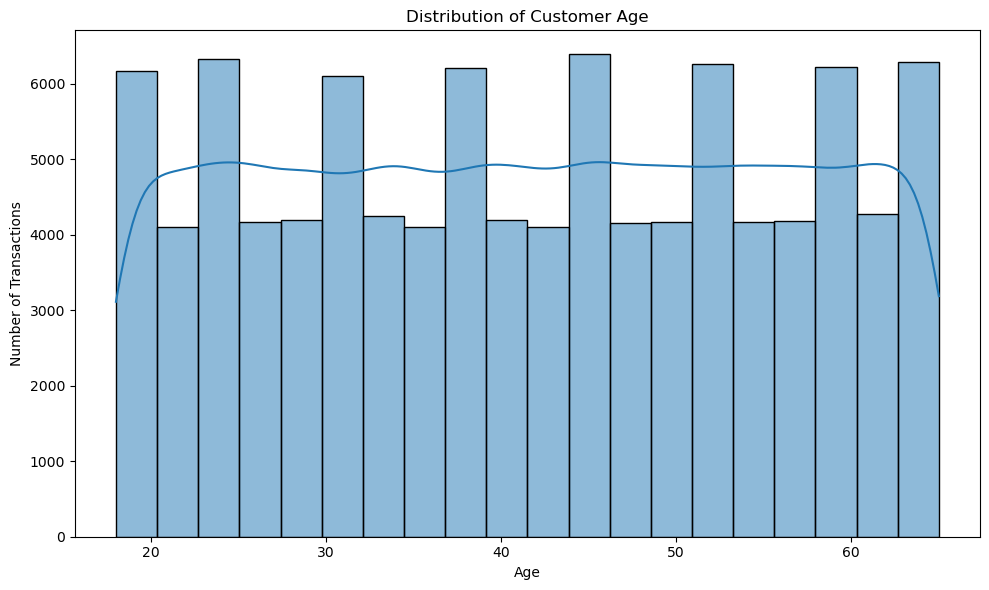

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='age',
    bins=20,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

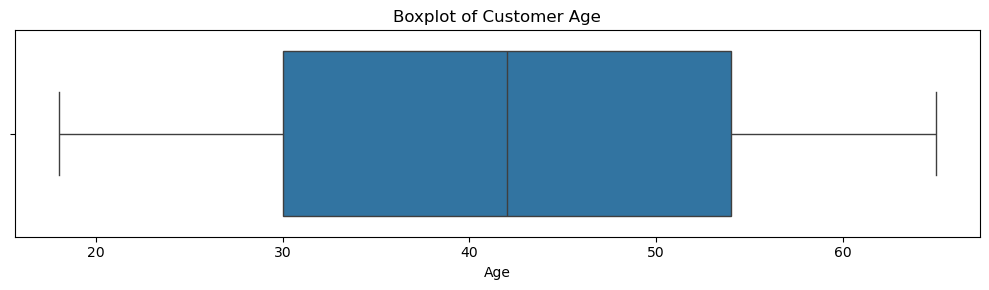

In [46]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='age'
)

plt.title('Boxplot of Customer Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

### Age — Observation

The age distribution is relatively even across the observed range of 18 to 65
years, with no strong concentration around a particular age group. The mean
(41.56 years) and median (42 years) are very close, while the near-zero
skewness indicates an approximately symmetric distribution.

The boxplot shows a broad but balanced spread of ages, with no prominent
outlier observations visible.

### Interpretation

The customer base represented in the dataset is broadly distributed across
the observed adult age range rather than being concentrated within a narrow
age group. Since no substantial skewness or extreme observations are apparent,
age can be treated as a relatively stable demographic variable for subsequent
bivariate and multivariate analysis.

## 3.3 Product Price

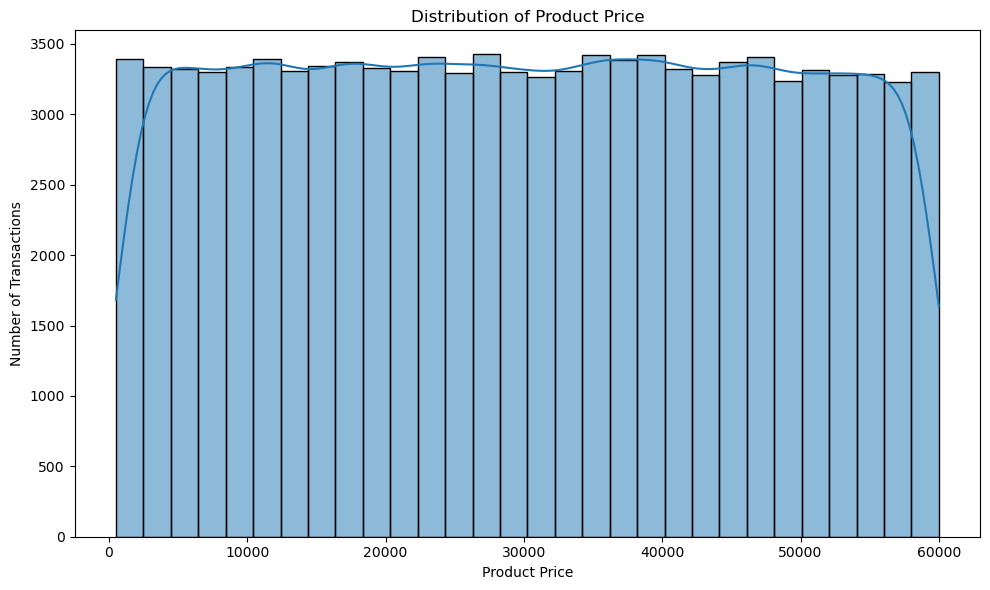

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='product_price',
    bins=30,
    kde=True
)

plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

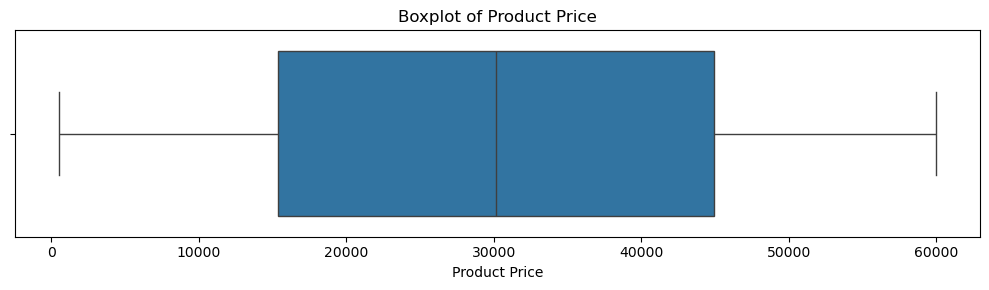

In [48]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='product_price'
)

plt.title('Boxplot of Product Price')
plt.xlabel('Product Price')
plt.tight_layout()
plt.show()

### Product Price — Observation

The product price distribution is broadly spread across the observed range of
₹500 to approximately ₹60,000. The histogram and KDE show a relatively even
distribution without a pronounced concentration toward either end.

The mean (₹30,164.53) and median (₹30,148) are almost identical, while the
skewness is approximately zero, indicating an approximately symmetric
distribution.

The boxplot shows a wide interquartile range with no prominent observations
outside the whiskers.

### Interpretation

Product prices are distributed relatively evenly across the observed price
range. Unlike the positive skew described as an example in the project
specification, the actual dataset does not show substantial skewness in
`product_price`.

The variable does not currently show strong evidence of extreme isolated
observations, although formal outlier detection will be performed separately.

## 3.4 Quantity Analysis

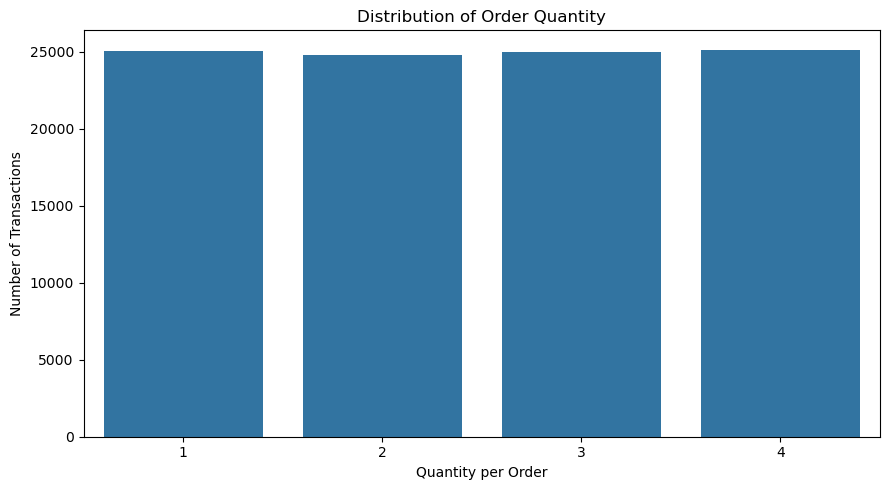

In [49]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_eda,
    x='quantity'
)

plt.title('Distribution of Order Quantity')
plt.xlabel('Quantity per Order')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Quantity — Observation

The order quantity variable contains four possible values: 1, 2, 3 and 4.
The frequency distribution shows that these quantities occur at broadly similar
rates, with no single quantity dominating the dataset.

The mean quantity is 2.50 and the median is 3, while the near-zero skewness
indicates that the distribution is approximately balanced.

### Interpretation

Customer orders are fairly evenly distributed across the four available
quantity levels. This suggests that the dataset does not have a strong tendency
toward either very small or very large quantities.

## 3.5 Discount Percentage 

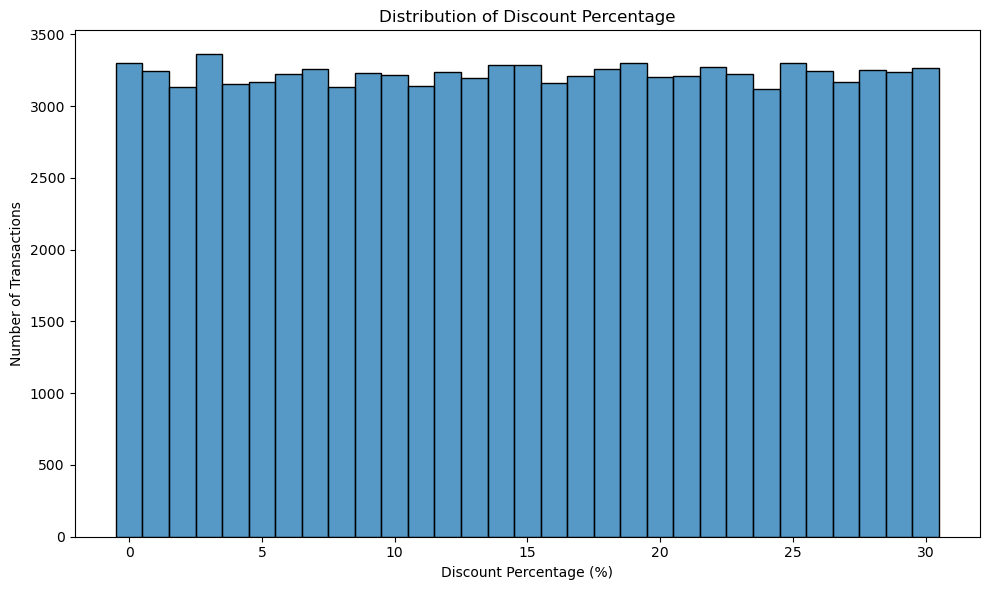

In [50]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='discount_percentage',
    discrete=True
)

plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

### Discount Percentage — Observation

The discount percentage is distributed relatively evenly across the observed
range of 0% to 30%. No individual discount level dominates the distribution,
indicating an approximately uniform pattern.

The mean discount is 15.01%, while the median is 15%, and the skewness is
approximately zero, supporting the visual observation of a balanced
distribution.

### Interpretation

Discounts are broadly distributed across the full 0–30% range rather than
being concentrated around a small number of discount levels. The presence of
3,300 transactions with a 0% discount indicates that a portion of purchases
were made without a discount.

## 3.6 Final Price 


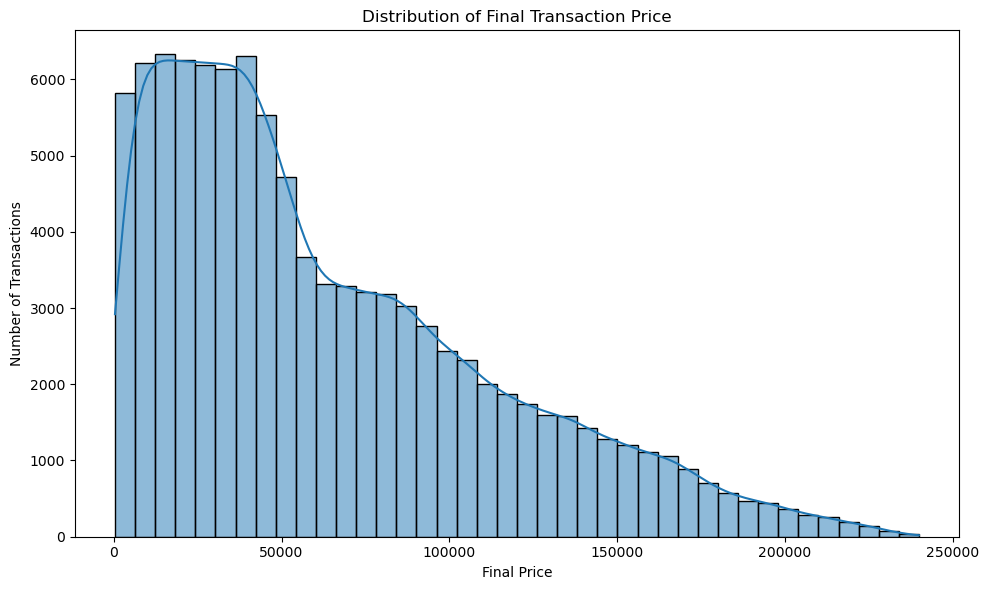

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='final_price',
    bins=40,
    kde=True
)

plt.title('Distribution of Final Transaction Price')
plt.xlabel('Final Price')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

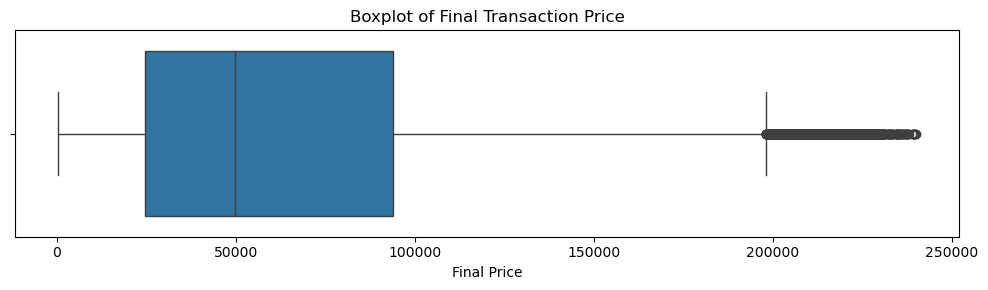

In [52]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='final_price'
)

plt.title('Boxplot of Final Transaction Price')
plt.xlabel('Final Price')
plt.tight_layout()
plt.show()

### Final Price — Observation

The final transaction price exhibits a pronounced right-skewed distribution.
Most transactions are concentrated in the lower-to-middle price range, while
the frequency of transactions decreases progressively toward higher values.

The mean final price (₹64,165.72) is considerably higher than the median
(₹49,752.39), and the skewness value of 0.93 confirms positive asymmetry.

The boxplot shows numerous observations beyond the upper whisker, indicating
the presence of extreme high-value transactions.

### Interpretation

The distribution suggests that transaction values are concentrated around
lower and medium price levels, while a smaller number of high-value purchases
extend the upper tail and increase the average transaction value.

These extreme observations should not automatically be considered erroneous.
They will be examined formally using the IQR and Z-score methods during the
dedicated outlier analysis stage.

### Advanced View: Log-Transformed Final Price

Because the final price distribution is strongly right-skewed, a logarithmic
transformation is used to provide a clearer view of the distribution across
different price magnitudes.

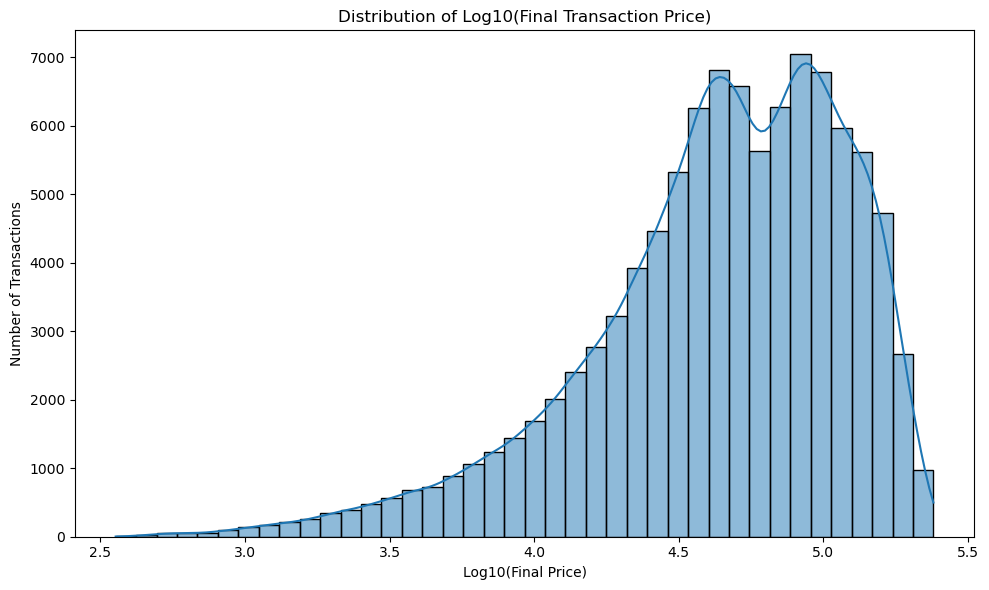

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(df_eda['final_price']),
    bins=40,
    kde=True
)

plt.title('Distribution of Log10(Final Transaction Price)')
plt.xlabel('Log10(Final Price)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Log-Transformed Final Price — Observation

The logarithmic transformation compresses the wide range of final transaction
prices and makes the distribution of lower- and higher-value transactions easier
to compare visually.

Compared with the original distribution, the transformed view reduces the
influence of the extreme upper tail and provides a clearer representation of
the main concentration of transaction values.

### Interpretation

The log-transformed visualization confirms that the original right-skewness is
primarily associated with the wide range of transaction values and the presence
of relatively high-value purchases. The transformation is used only as an
analytical visualization technique; the original `final_price` values remain
unchanged in the dataset.

## 3.7 Delivery Days

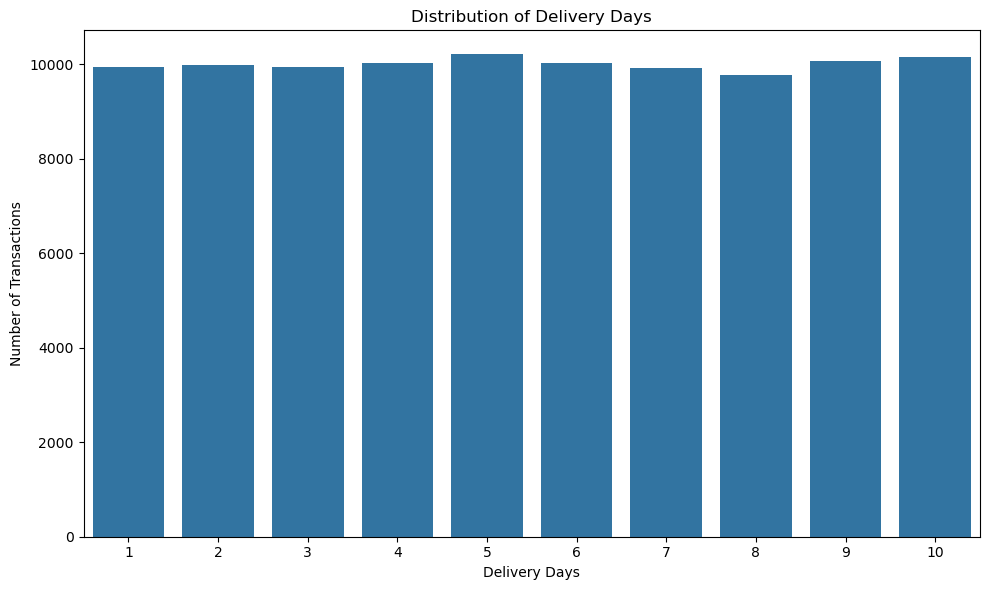

In [54]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda,
    x='delivery_days'
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

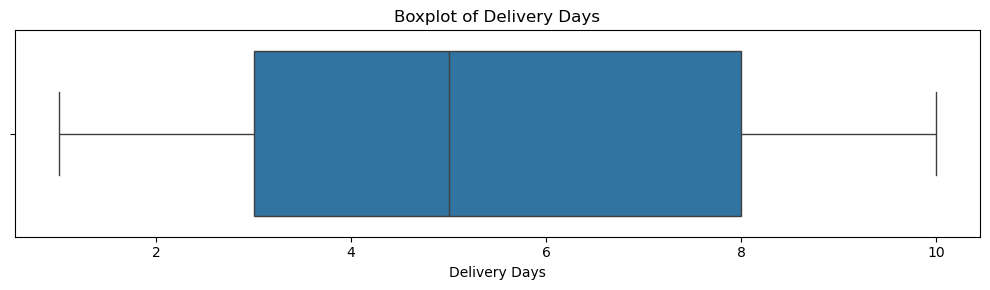

In [55]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='delivery_days'
)

plt.title('Boxplot of Delivery Days')
plt.xlabel('Delivery Days')
plt.tight_layout()
plt.show()

### Delivery Days — Observation

Delivery times range from 1 to 10 days and are distributed relatively evenly
across the available values. No single delivery duration accounts for a
substantially larger share of transactions.

The mean delivery time is 5.51 days, while the median is 5 days. The
approximately zero skewness indicates a balanced distribution with little
asymmetry.

The boxplot shows a spread from 1 to 10 days without prominent observations
outside the whiskers.

### Interpretation

The dataset represents a relatively balanced distribution of delivery
durations rather than being heavily concentrated around very short or very long
delivery times. No prominent extreme observations are visible in the basic
boxplot, although formal outlier detection will be performed separately.

## 3.8 Comparative Skewness Analysis

Skewness is compared across the numerical variables to identify variables with
substantial distributional asymmetry. This provides a compact comparison of the
individual distribution analyses performed above.

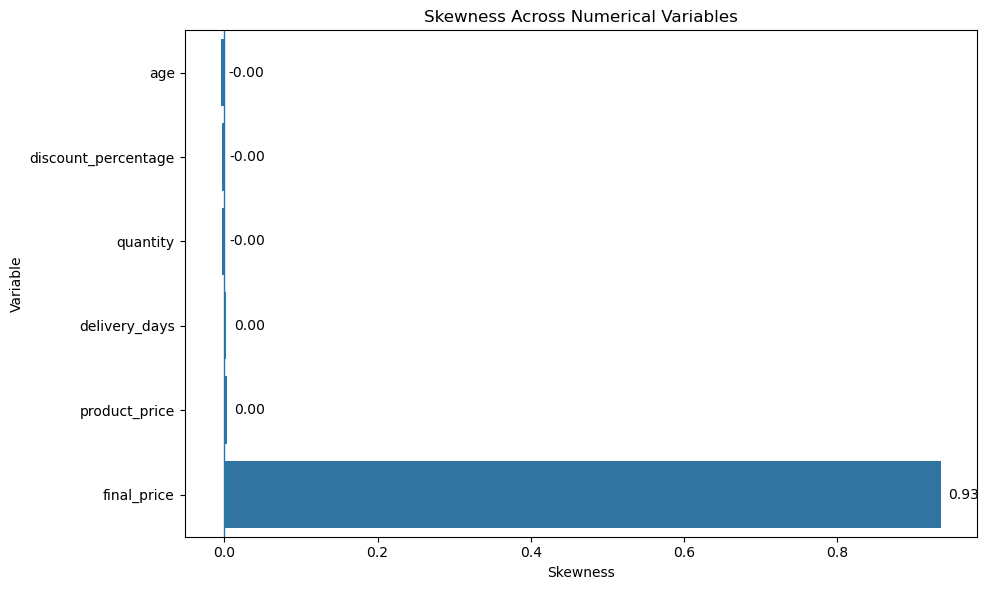

In [57]:
plt.figure(figsize=(10, 6))

skewness_values = numerical_stats['Skewness'].sort_values()

ax = sns.barplot(
    x=skewness_values.values,
    y=skewness_values.index
)

for i, value in enumerate(skewness_values.values):
    ax.text(
        value + 0.01,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.axvline(0, linewidth=1)
plt.title('Skewness Across Numerical Variables')
plt.xlabel('Skewness')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Comparative Skewness — Observation

The comparative skewness analysis shows that most numerical variables have
skewness values close to zero, indicating approximately symmetric distributions.

In contrast, `final_price` has a skewness of 0.93, making it the only numerical
variable with noticeable positive asymmetry.

### Interpretation

The distribution of most numerical variables is relatively balanced, whereas
`final_price` has a pronounced right-skewed distribution caused by a smaller
number of higher-value transactions extending the upper tail.

This makes `final_price` the primary numerical variable requiring further
attention during outlier and distribution analysis.

# 4. Categorical Univariate Analysis

Categorical univariate analysis examines the frequency and relative distribution
of individual categorical variables. The analysis is used to understand the
composition of customers, geographic coverage, product categories, transaction
methods, shipping methods and return outcomes.

## 4.1 Customer Demographics

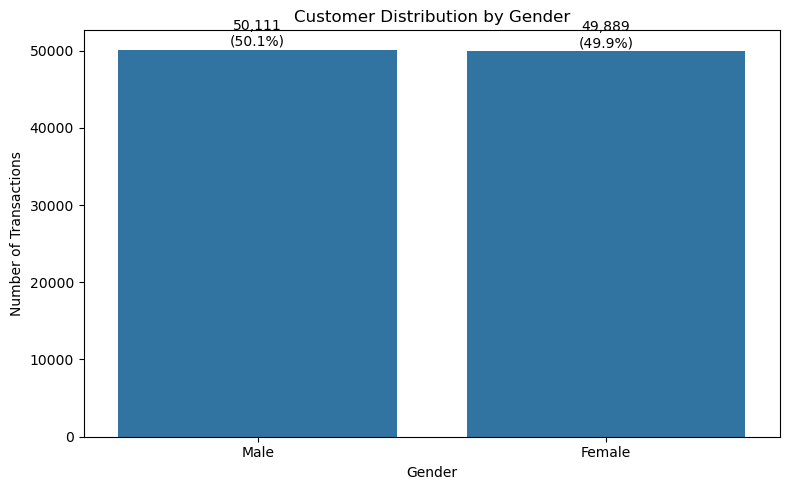

In [58]:
gender_counts = df_eda['gender'].value_counts()
gender_percent = df_eda['gender'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

for i, (count, percent) in enumerate(zip(gender_counts.values, gender_percent.values)):
    ax.text(
        i,
        count + 500,
        f'{count:,}\n({percent:.1f}%)',
        ha='center'
    )

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Gender — Observation

The gender distribution is almost evenly balanced, with male customers
representing 50.1% of the transactions and female customers representing
49.9%.

### Interpretation

Neither gender category dominates the dataset. The near-equal representation
provides a balanced basis for examining gender-related differences in later
bivariate and multivariate analysis.

## 4.2 City

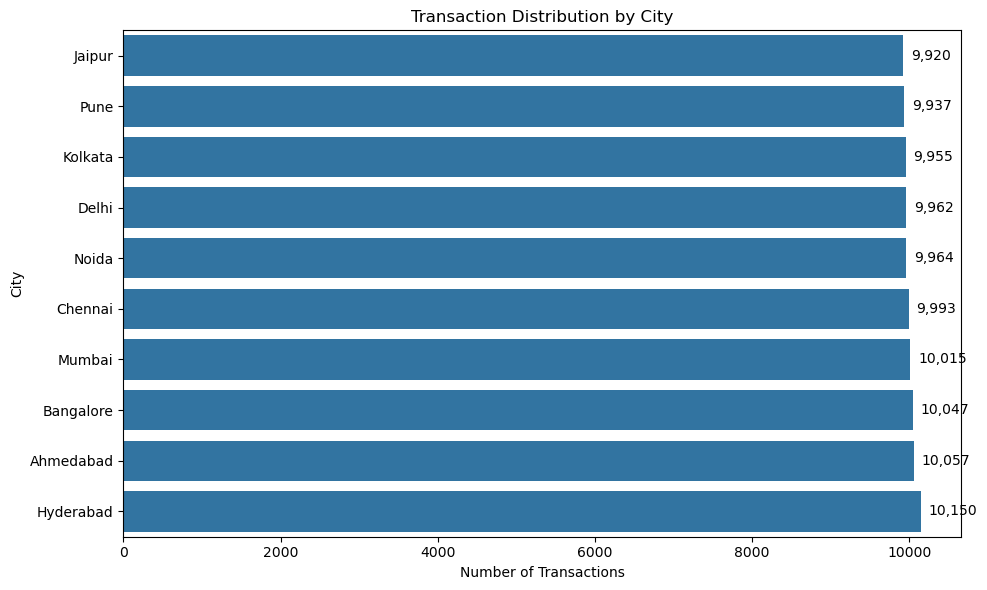

In [59]:
city_counts = df_eda['city'].value_counts().sort_values()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

for i, value in enumerate(city_counts.values):
    ax.text(
        value + 100,
        i,
        f'{value:,}',
        va='center'
    )

plt.title('Transaction Distribution by City')
plt.xlabel('Number of Transactions')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### City — Observation

Transaction counts are distributed very evenly across the ten cities. The
number of transactions ranges from 9,920 in Jaipur to 10,150 in Hyderabad,
with only a small difference between the lowest and highest counts.

### Interpretation

The dataset provides broadly balanced geographic representation across the
ten cities. No single city contributes a disproportionately large share of
transactions, reducing the likelihood that the overall analysis is dominated
by one geographic location.

## 4.3 State

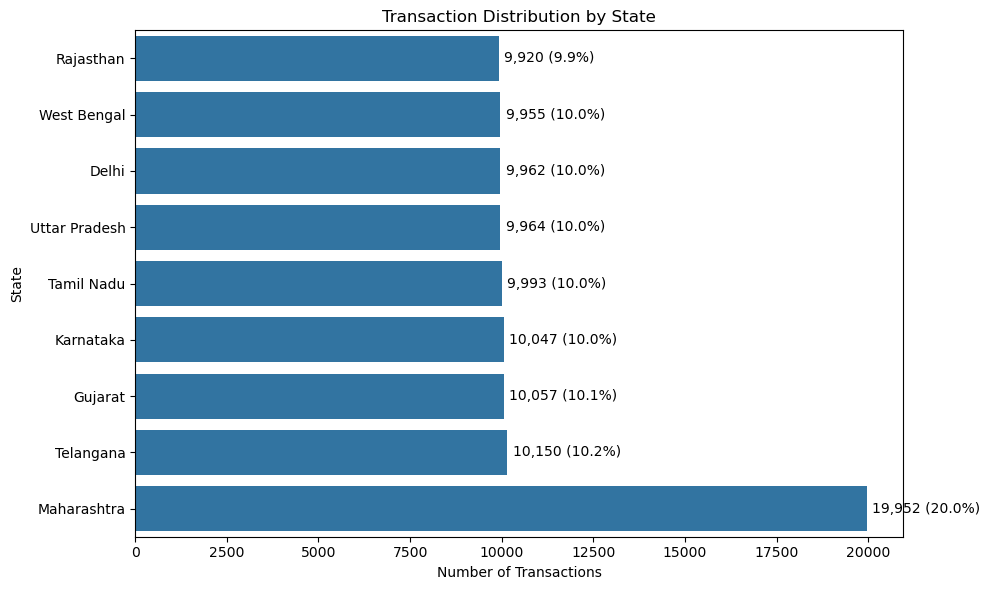

In [60]:
state_counts = df_eda['state'].value_counts().sort_values()
state_percent = (state_counts / len(df_eda)) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)

for i, (count, percent) in enumerate(zip(state_counts.values, state_percent.values)):
    ax.text(
        count + 150,
        i,
        f'{count:,} ({percent:.1f}%)',
        va='center'
    )

plt.title('Transaction Distribution by State')
plt.xlabel('Number of Transactions')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### State — Observation

The state-level distribution shows that Maharashtra accounts for the largest
share of transactions, with 19,952 records representing approximately 20.0%
of the dataset.

Most of the remaining states contribute close to 10% each, while Rajasthan
has the lowest transaction count at 9,920 records (9.9%).

### Interpretation

The higher transaction share of Maharashtra is consistent with the presence of
two cities from the dataset, Mumbai and Pune, within the same state. Therefore,
the state-level distribution is more uneven than the city-level distribution.

This difference should be considered when comparing geographic patterns in
later bivariate analysis.

## 4.4 Customer Segment

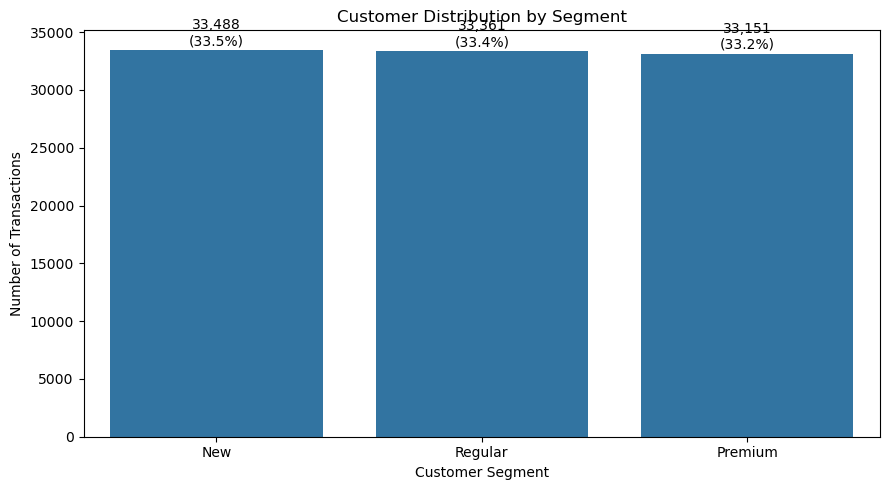

In [61]:
segment_counts = df_eda['customer_segment'].value_counts()
segment_percent = df_eda['customer_segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

for i, (count, percent) in enumerate(
    zip(segment_counts.values, segment_percent.values)
):
    ax.text(
        i,
        count + 400,
        f'{count:,}\n({percent:.1f}%)',
        ha='center'
    )

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Customer Segment — Observation

The three customer segments are represented almost equally in the dataset.
New customers account for 33.5% of transactions, Regular customers account
for 33.4%, and Premium customers account for 33.2%.

### Interpretation

The customer-segment distribution is highly balanced, with no segment
contributing a disproportionately large share of transactions. This balanced
representation is useful for subsequent comparisons of spending, purchasing
behavior and other transaction characteristics across customer segments.

## 4.5 Product Category 

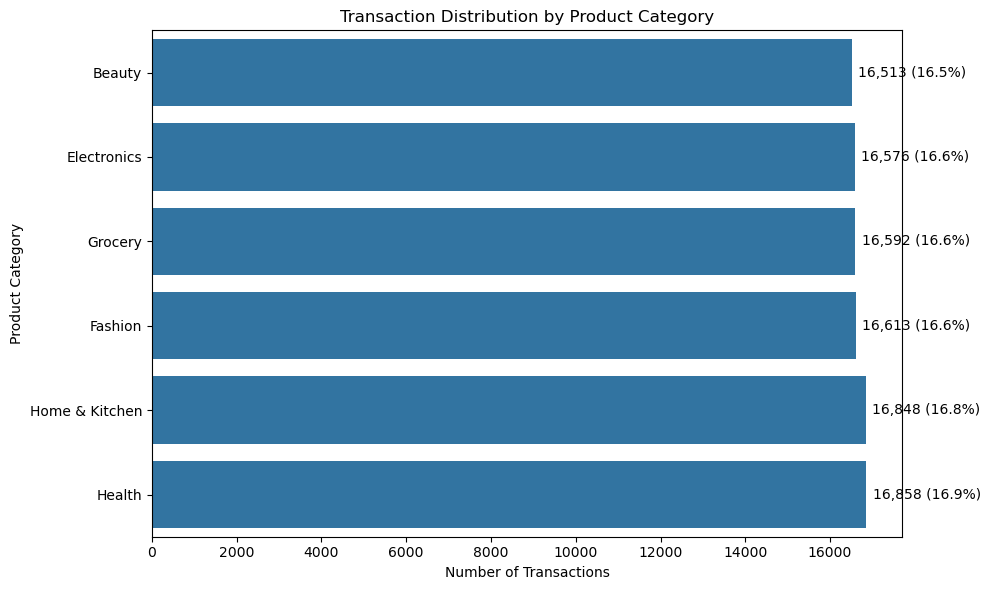

In [62]:
category_counts = df_eda['product_category'].value_counts().sort_values()
category_percent = (category_counts / len(df_eda)) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

for i, (count, percent) in enumerate(
    zip(category_counts.values, category_percent.values)
):
    ax.text(
        count + 150,
        i,
        f'{count:,} ({percent:.1f}%)',
        va='center'
    )

plt.title('Transaction Distribution by Product Category')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### Product Category — Observation

Transaction counts are distributed very evenly across all six product
categories. Health has the highest number of transactions with 16,858
records (16.9%), while Beauty has the lowest with 16,513 records (16.5%).

The difference between the highest and lowest categories is only 345
transactions, indicating a highly balanced category distribution.

### Interpretation

No individual product category dominates the transaction volume. The
balanced representation provides a useful basis for comparing categories on
other measures such as final price, discount levels and return rates during
bivariate and multivariate analysis.

Although the project specification provides Electronics as an example of a
high-transaction category, the actual dataset shows Health with the highest
transaction count.

## 4.6 Product Subcategory

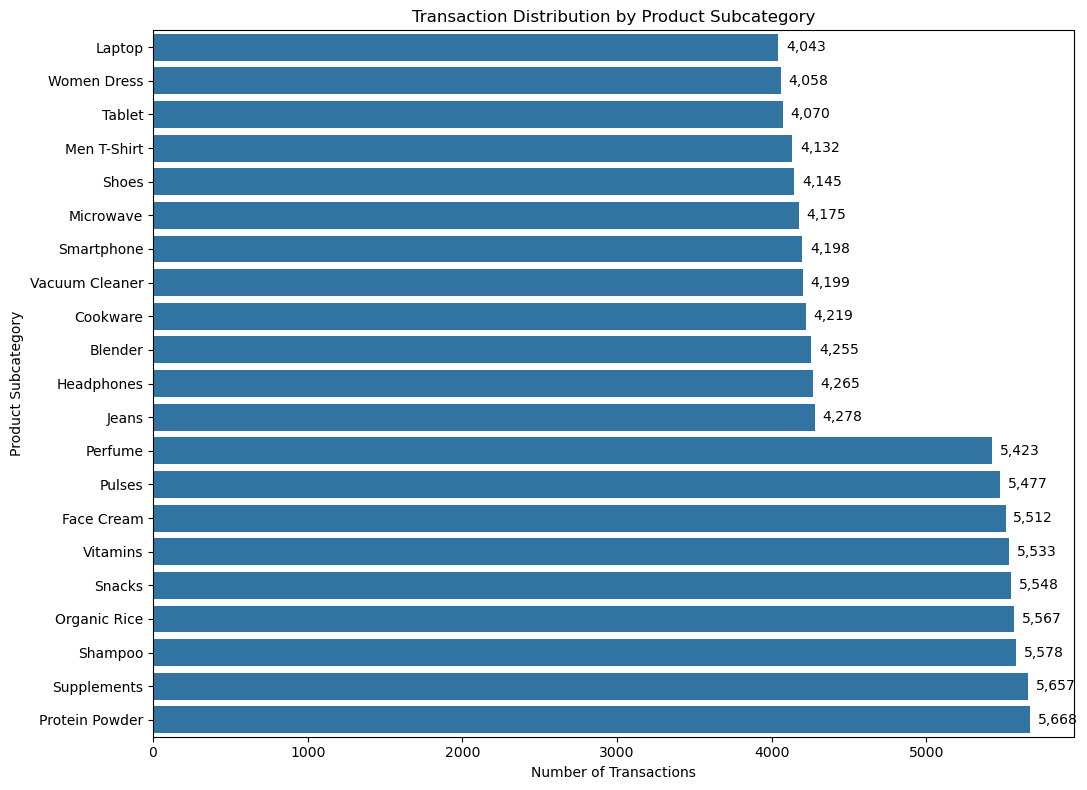

In [63]:
subcategory_counts = (
    df_eda['product_subcategory']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    x=subcategory_counts.values,
    y=subcategory_counts.index
)

for i, value in enumerate(subcategory_counts.values):
    ax.text(
        value + 50,
        i,
        f'{value:,}',
        va='center'
    )

plt.title('Transaction Distribution by Product Subcategory')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Subcategory')
plt.tight_layout()
plt.show()

### Product Subcategory — Observation

The transaction distribution across the 21 product subcategories is more
variable than the distribution across the six parent product categories.

Protein Powder has the highest transaction count at 5,668, followed closely by
Supplements at 5,657. In contrast, Laptop has the lowest count at 4,043,
followed by Women Dress and Tablet.

Several subcategories cluster around 4,000–4,300 transactions, while another
group records approximately 5,400–5,700 transactions.

### Interpretation

Although the overall product-category distribution is highly balanced, the
distribution becomes more differentiated at the subcategory level. This
suggests that some specific products contribute more frequently to transaction
volume than others.

However, transaction frequency alone does not indicate which subcategories
generate the highest revenue or profit. Those relationships will be examined
later using bivariate and multivariate analysis.

## 4.7 Payment Method

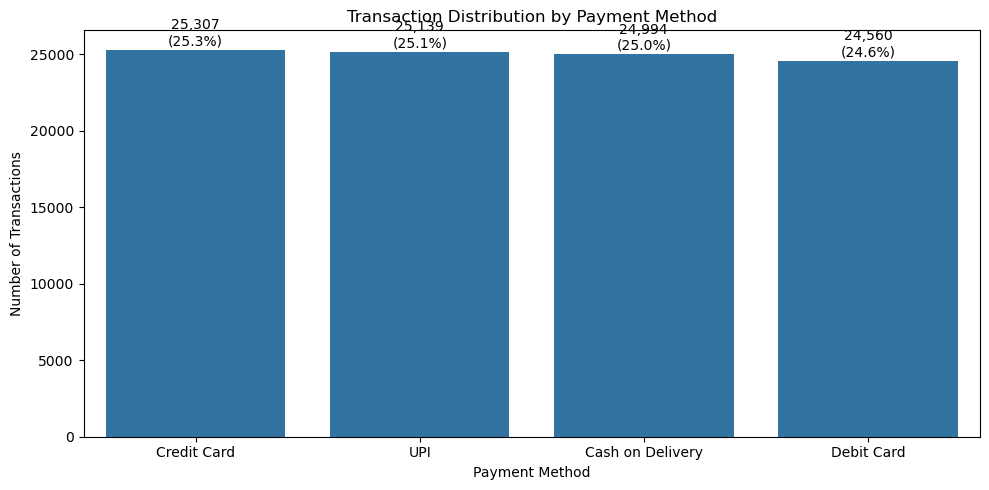

In [64]:
payment_counts = df_eda['payment_method'].value_counts().sort_values(ascending=False)
payment_percent = (payment_counts / len(df_eda)) * 100

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

for i, (count, percent) in enumerate(
    zip(payment_counts.values, payment_percent.values)
):
    ax.text(
        i,
        count + 300,
        f'{count:,}\n({percent:.1f}%)',
        ha='center'
    )

plt.title('Transaction Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Payment Method — Observation

Transaction counts are distributed relatively evenly across all four payment
methods. Credit Card has the highest transaction count at 25,307 (25.3%),
while Debit Card has the lowest at 24,560 (24.6%).

The small difference between the payment methods indicates a highly balanced
distribution.

### Interpretation

No single payment method dominates the transaction dataset. This balanced
representation provides a suitable basis for later analysis of whether payment
method is associated with transaction value, customer segment or return
behavior.

## 4.8 Shipping Type

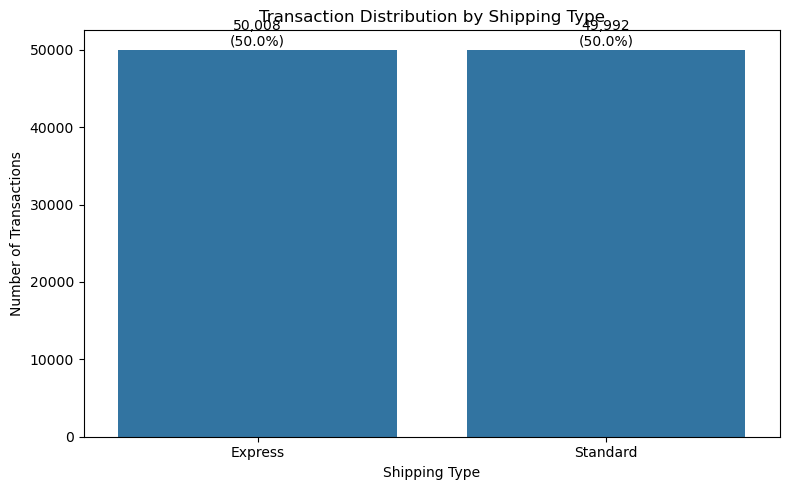

In [65]:
shipping_counts = df_eda['shipping_type'].value_counts()
shipping_percent = df_eda['shipping_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=shipping_counts.index,
    y=shipping_counts.values
)

for i, (count, percent) in enumerate(
    zip(shipping_counts.values, shipping_percent.values)
):
    ax.text(
        i,
        count + 500,
        f'{count:,}\n({percent:.1f}%)',
        ha='center'
    )

plt.title('Transaction Distribution by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Shipping Type — Observation

The distribution of shipping types is almost perfectly balanced. Express
shipping accounts for 50,008 transactions (50.0%), while Standard shipping
accounts for 49,992 transactions (50.0%).

The difference between the two categories is only 16 transactions.

### Interpretation

Neither shipping type dominates the dataset. The near-equal representation
provides a balanced basis for comparing delivery performance and return
behavior between Express and Standard shipping in subsequent bivariate and
multivariate analysis.

## 4.9 Return Status

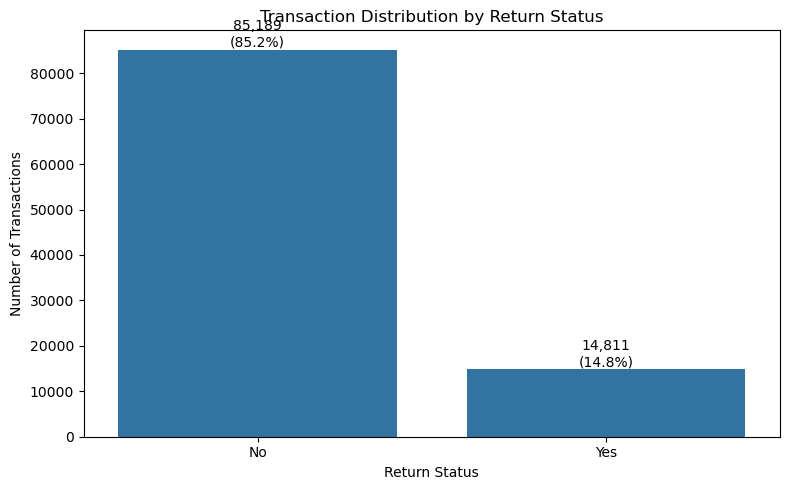

In [66]:
return_counts = df_eda['return_status'].value_counts()
return_percent = df_eda['return_status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=return_counts.index,
    y=return_counts.values
)

for i, (count, percent) in enumerate(
    zip(return_counts.values, return_percent.values)
):
    ax.text(
        i,
        count + 700,
        f'{count:,}\n({percent:.1f}%)',
        ha='center'
    )

plt.title('Transaction Distribution by Return Status')
plt.xlabel('Return Status')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Return Status — Observation

The majority of transactions were not returned, with 85,189 transactions
(85.2%) having a return status of `No`. A total of 14,811 transactions
(14.8%) were marked as returned.

### Interpretation

The overall return rate in the dataset is approximately 14.8%, meaning that
returned transactions represent a smaller proportion of the total transaction
volume.

This overall rate provides a useful baseline for later bivariate analysis,
where return behavior will be examined in relation to product category,
delivery time, shipping type and other transaction characteristics.

## 4.10 Categorical Distribution Summary

The following table summarizes the number of unique categories and the most
frequent category for each categorical variable.

In [67]:
categorical_summary = pd.DataFrame({
    'Unique Categories': df_eda[categorical_columns].nunique(),
    'Most Frequent Category': [
        df_eda[col].value_counts().idxmax()
        for col in categorical_columns
    ],
    'Highest Category Count': [
        df_eda[col].value_counts().max()
        for col in categorical_columns
    ]
})

categorical_summary

,Unique Categories,Most Frequent Category,Highest Category Count
gender,2,Male,50111
city,10,Hyderabad,10150
state,9,Maharashtra,19952
customer_segment,3,New,33488
product_category,6,Health,16858
product_subcategory,21,Protein Powder,5668
payment_method,4,Credit Card,25307
shipping_type,2,Express,50008
return_status,2,No,85189


### Observation

The categorical summary confirms that the dataset contains a manageable and
well-defined set of categories across customer, geographic, product and
transaction-related variables.

The most frequent categories identified in the summary are consistent with the
individual frequency visualizations performed above. The categorical variables
will therefore be suitable for subsequent comparative and relationship-based
analysis.

## 4.11 Temporal Univariate Analysis

### Monthly Transaction Trend

The order date is analyzed over time to identify changes in transaction volume
across the observed period.

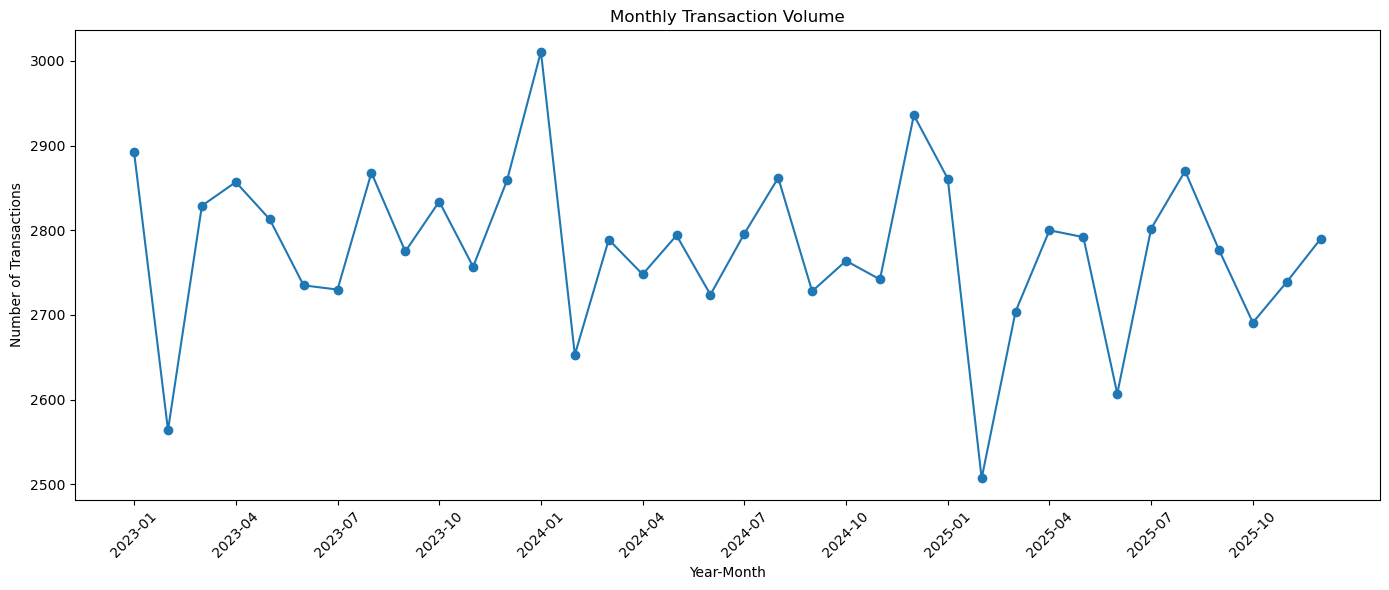

In [69]:
monthly_transactions = (
    df_eda.groupby('order_year_month')
    .size()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values,
    marker='o'
)

plt.title('Monthly Transaction Volume')
plt.xlabel('Year-Month')
plt.ylabel('Number of Transactions')

plt.xticks(
    range(0, len(monthly_transactions), 3),
    monthly_transactions.index.astype(str)[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

### Monthly Transaction Trend — Observation

Monthly transaction volume fluctuates throughout the period from 2023 to 2025,
generally remaining within the range of approximately 2,500 to 3,000
transactions per month.

The highest observed monthly volume is approximately 3,010 transactions around
January 2024, while the lowest is approximately 2,507 transactions around
February 2025.

### Interpretation

The monthly transaction pattern does not show a clear long-term upward or
downward trend. Instead, transaction activity varies from month to month while
remaining within a relatively consistent overall range.

The line chart alone does not provide strong evidence of a recurring seasonal
pattern. A year-by-month comparison will be useful for examining whether some
months consistently perform differently across the three years.

## 4.12 Year-Month Transaction Heatmap

A year-by-month heatmap is used to compare transaction volumes across the same
calendar months in different years. This helps identify recurring seasonal
patterns that may not be obvious from the overall monthly trend.

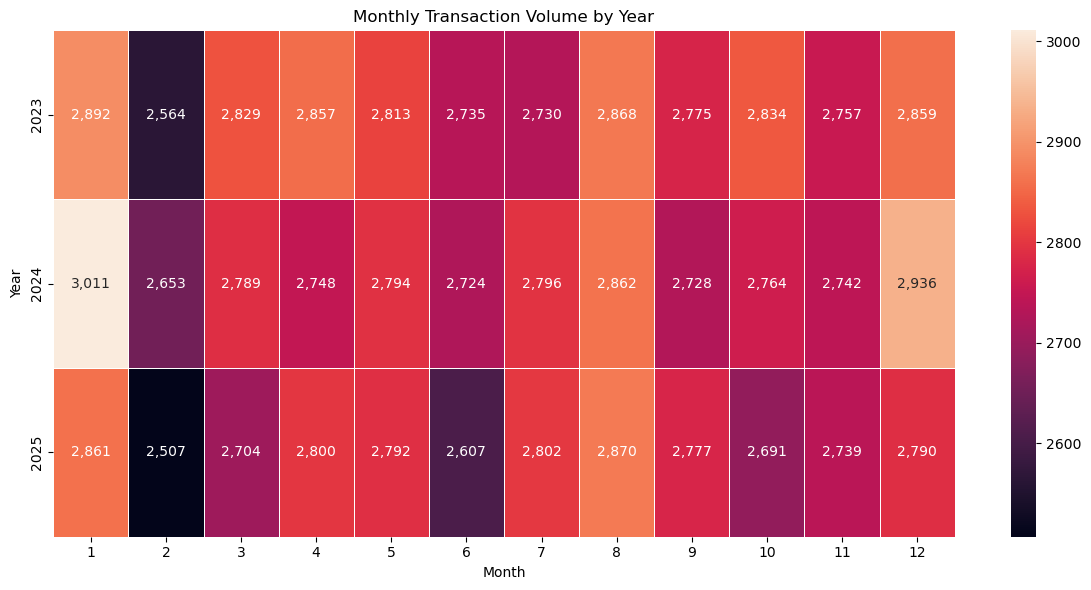

In [70]:
monthly_heatmap = (
    df_eda.groupby([
        'order_year',
        'order_month'
    ])
    .size()
    .unstack()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly_heatmap,
    annot=True,
    fmt=',.0f',
    linewidths=0.5
)

plt.title('Monthly Transaction Volume by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### Year-Month Heatmap — Observation

The year-month heatmap shows that monthly transaction volumes remain within a
relatively narrow range across all three years, while certain month-level
patterns can be observed.

February records the lowest transaction volume in each year, with 2,564
transactions in 2023, 2,653 in 2024 and 2,507 in 2025. January is consistently
among the higher-volume months, reaching 3,011 transactions in 2024.
December also shows relatively high activity, particularly in 2024 with 2,936
transactions.

### Interpretation

The repeated lower transaction volume in February across all three years
suggests a possible recurring seasonal pattern in the dataset. However, the
variation across other months is not sufficiently consistent to conclude that
there is a strong overall seasonal cycle.

The heatmap therefore provides evidence of some recurring monthly behavior
while also showing that transaction activity remains broadly stable over the
three-year period.

# 5. Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify
patterns, associations, trends and differences.

The analysis includes numerical-to-numerical, numerical-to-categorical and
categorical-to-categorical relationships using appropriate statistical and
visualization techniques.

## 5.1 Numerical × Numerical Analysis

### Product Price vs Final Price

The relationship between product price and final transaction price is examined
using a scatter plot and Pearson correlation.

The analysis helps determine the direction and strength of the relationship
between the two monetary variables.

## Pearson Correlation

In [105]:
product_final_corr = df_eda['product_price'].corr(
    df_eda['final_price'],
    method='pearson'
)

print(f"Pearson correlation: {product_final_corr:.4f}")

Pearson correlation: 0.7308


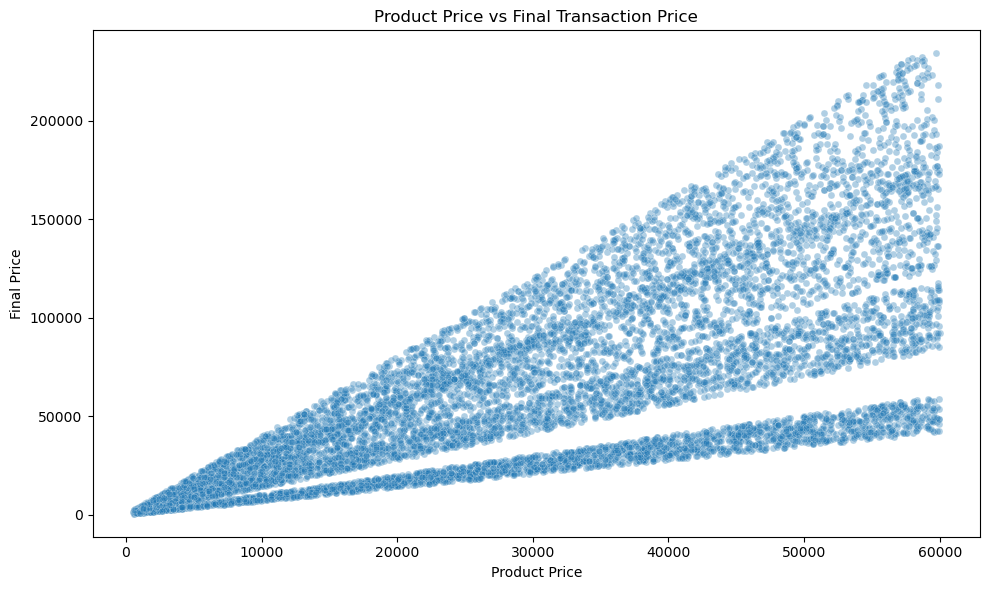

In [106]:
plot_sample = df_eda.sample(
    10000,
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x='product_price',
    y='final_price',
    alpha=0.35,
    s=25
)

plt.title('Product Price vs Final Transaction Price')
plt.xlabel('Product Price')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

## Regression Relationship

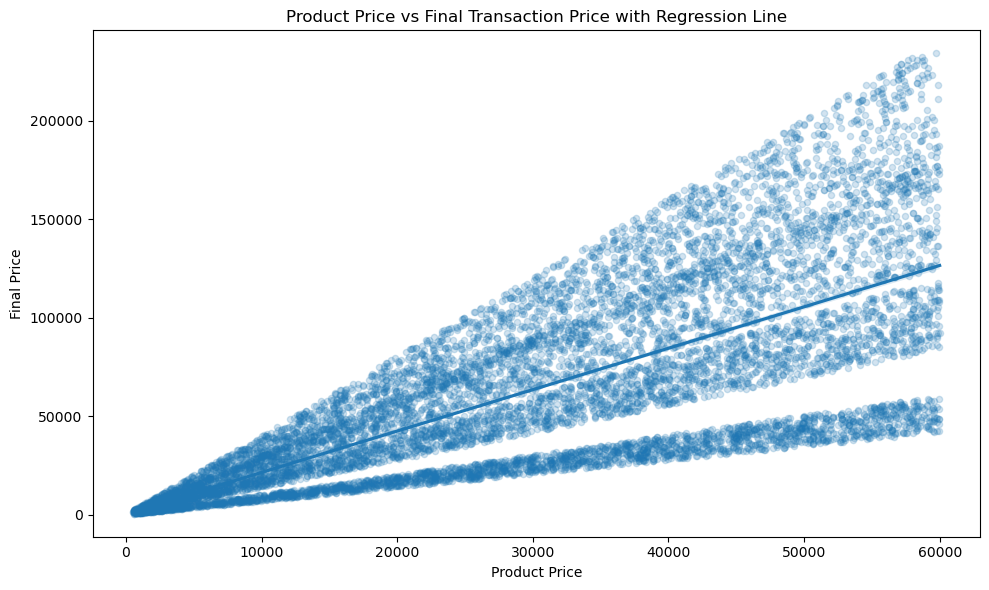

In [107]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=plot_sample,
    x='product_price',
    y='final_price',
    scatter_kws={'alpha': 0.2, 's': 20},
    line_kws={}
)

plt.title('Product Price vs Final Transaction Price with Regression Line')
plt.xlabel('Product Price')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

### Product Price vs Final Price — Observation

The scatter plot shows a clear positive relationship between product price and
final transaction price. Higher product prices are generally associated with
higher final prices, although the observations spread across several bands.

The Pearson correlation coefficient is 0.7308, indicating a strong positive
linear association between the two variables.

The regression line further confirms the overall upward trend.

### Interpretation

The positive relationship is expected because product price is a direct
component of the final transaction price. However, the vertical spread of
observations indicates that other transaction factors, particularly quantity
and discount percentage, also influence the final price.

Therefore, product price alone does not fully explain variation in final price.
The interaction of these variables will be investigated further through
multivariate analysis.

## Quantity vs Final Price

The relationship between order quantity and final transaction price is
examined by comparing the distribution of final prices across different
quantity levels.

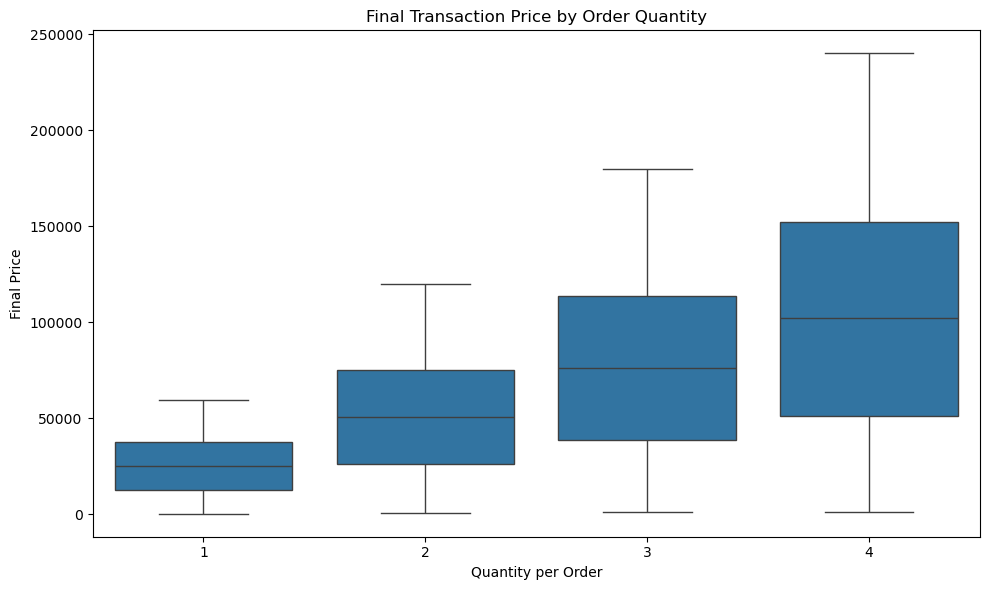

In [108]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_eda,
    x='quantity',
    y='final_price'
)

plt.title('Final Transaction Price by Order Quantity')
plt.xlabel('Quantity per Order')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

### Final Price Summary by Order Quantity

In [109]:
quantity_price_summary = (
    df_eda.groupby('quantity')['final_price']
    .agg(['mean', 'median'])
)

quantity_price_summary

,mean,median
quantity,,
1,25595.96,25140.06
2,51382.11,50846.40
3,76837.73,76031.16
4,102663.72,101975.86


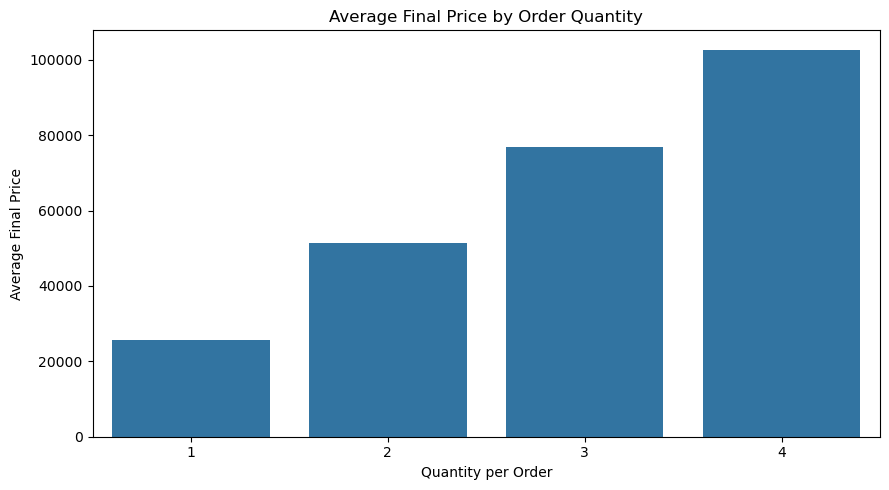

In [110]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_eda,
    x='quantity',
    y='final_price',
    errorbar=None
)

plt.title('Average Final Price by Order Quantity')
plt.xlabel('Quantity per Order')
plt.ylabel('Average Final Price')
plt.tight_layout()
plt.show()

### Quantity vs Final Price — Observation

The boxplot shows a clear upward shift in final transaction price as order
quantity increases. The median and overall distribution of final price are
higher for each successive quantity level.

The average final price increases from ₹25,595.96 for quantity 1 to
₹51,382.11 for quantity 2, ₹76,837.73 for quantity 3 and ₹102,663.72 for
quantity 4.

The mean and median values are also relatively close within each quantity
group, although the spread of final prices becomes wider at higher quantities.

### Interpretation

Higher order quantities are strongly associated with higher final transaction
values. This relationship is consistent with the pricing structure identified
during the data-quality validation, where final price is directly influenced by
product price, quantity and discount percentage.

The increasing spread at higher quantities also indicates greater variation in
transaction values for larger orders, which will be useful when examining
multivariate relationships involving product price and discount.

## Age vs Final Price

The relationship between customer age and final transaction price is examined
to determine whether transaction value varies systematically across different
age levels.

### Pearson correlation

In [111]:
age_final_corr = df_eda['age'].corr(
    df_eda['final_price'],
    method='pearson'
)

print(f"Pearson correlation: {age_final_corr:.4f}")

Pearson correlation: -0.0008


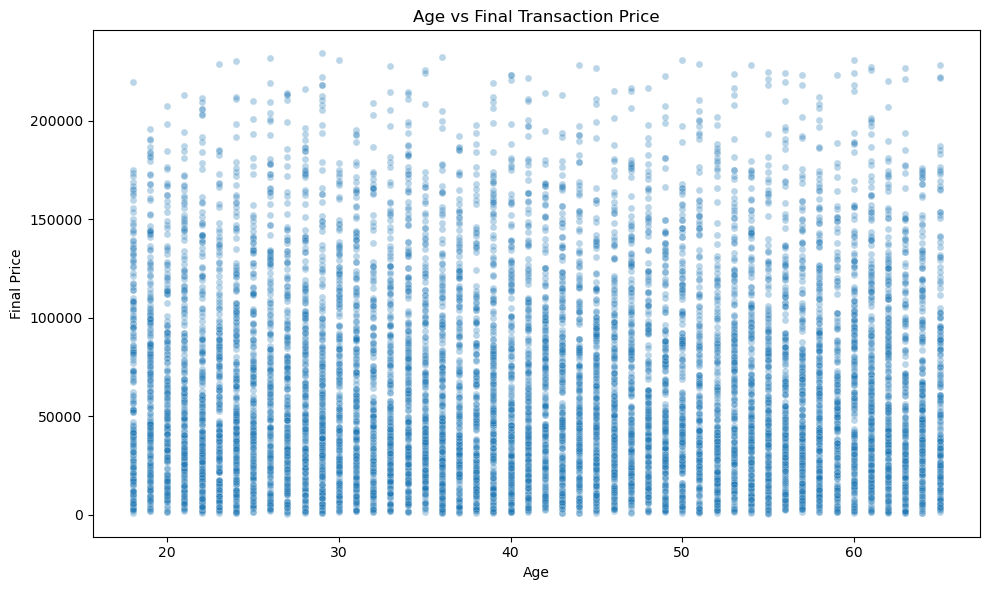

In [112]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x='age',
    y='final_price',
    alpha=0.3,
    s=25
)

plt.title('Age vs Final Transaction Price')
plt.xlabel('Age')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

### Trend line 

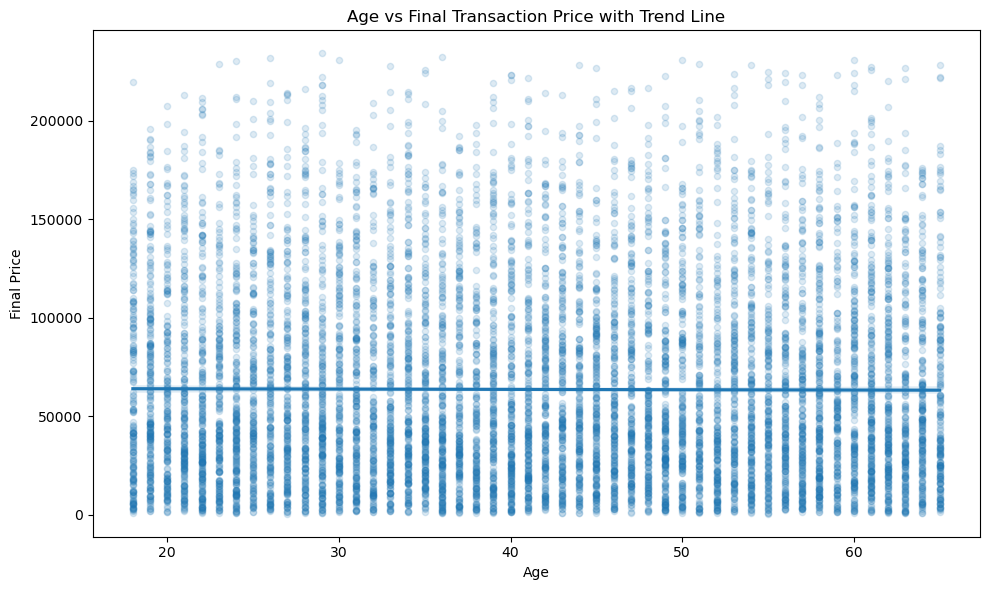

In [113]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=plot_sample,
    x='age',
    y='final_price',
    scatter_kws={'alpha': 0.15, 's': 20}
)

plt.title('Age vs Final Transaction Price with Trend Line')
plt.xlabel('Age')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

### Age vs Final Price — Observation

The scatter plot shows a broad and highly dispersed distribution of final
transaction prices across all age levels. No clear upward or downward pattern
is visible.

The Pearson correlation coefficient is -0.0008, which is effectively zero and
indicates no meaningful linear relationship between customer age and final
transaction price.

The nearly horizontal trend line provides additional visual confirmation of
the lack of a linear association.

### Interpretation

Customer age does not appear to be a meaningful linear indicator of final
transaction value in this dataset. Customers across the observed age range
can have both relatively low- and high-value transactions.

This suggests that other factors, such as product price, quantity, discount
percentage and customer segment, are likely to be more relevant when explaining
variation in final transaction price.

## Delivery Days vs Final Price

The relationship between delivery duration and final transaction price is
examined to determine whether transaction value varies systematically with
delivery time.

### Pearson correlation

In [114]:
delivery_final_corr = df_eda['delivery_days'].corr(
    df_eda['final_price'],
    method='pearson'
)

print(f"Pearson correlation: {delivery_final_corr:.4f}")

Pearson correlation: 0.0038


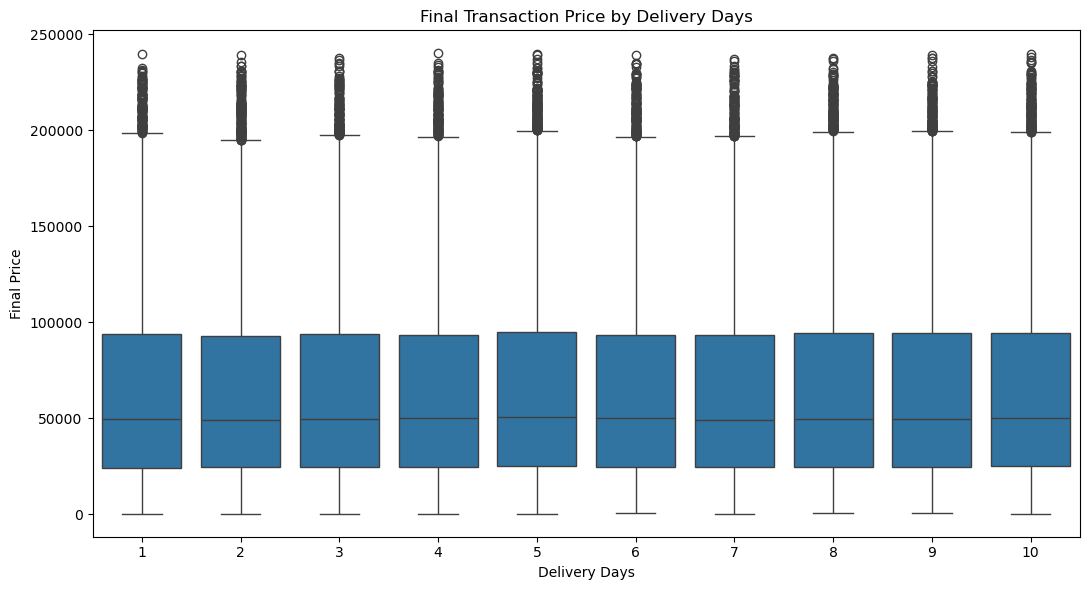

In [115]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_eda,
    x='delivery_days',
    y='final_price'
)

plt.title('Final Transaction Price by Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

### Delivery Days vs Final Price — Observation

The boxplot shows that the distribution of final transaction prices remains
broadly similar across delivery durations from 1 to 10 days. The medians and
interquartile ranges do not show a consistent upward or downward pattern.

The Pearson correlation coefficient is 0.0038, which is effectively zero and
indicates no meaningful linear relationship between delivery duration and
final transaction price.

### Interpretation

Delivery time does not appear to be a meaningful linear indicator of
transaction value in this dataset. High- and low-value transactions occur
across different delivery durations rather than being concentrated around a
specific delivery time.

The analysis also suggests that delivery performance should be investigated
primarily in relation to return behavior and shipping type rather than
transaction value.

## 5.2 Numerical × Categorical Analysis

### Customer Segment vs Final Price

The distribution of final transaction price is compared across customer
segments to determine whether transaction values differ between New, Regular
and Premium customers.

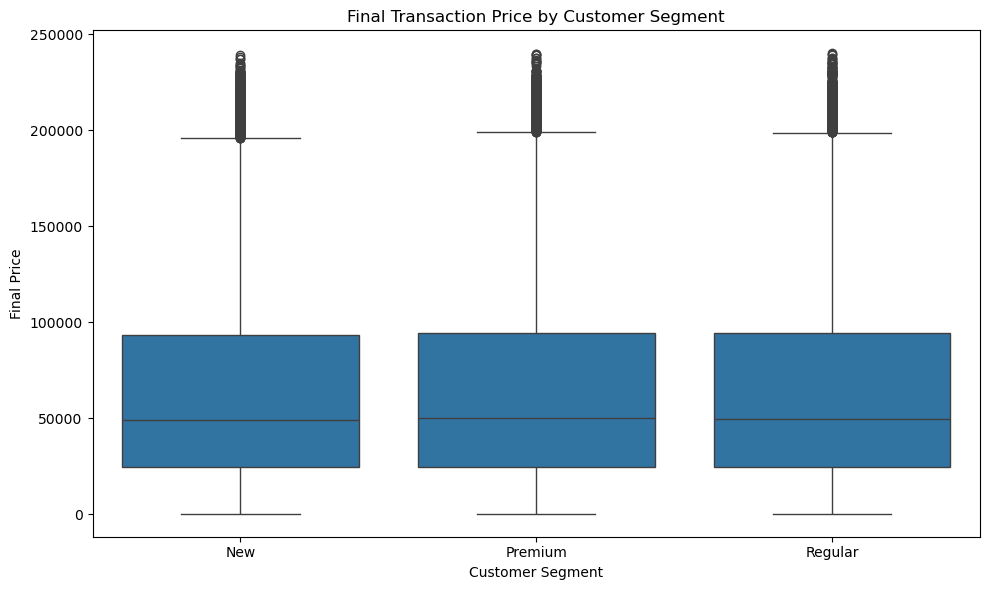

In [116]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_eda,
    x='customer_segment',
    y='final_price'
)

plt.title('Final Transaction Price by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

In [117]:
segment_price_summary = (
    df_eda.groupby('customer_segment')['final_price']
    .agg(['mean', 'median'])
    .sort_values('mean', ascending=False)
)

segment_price_summary

,mean,median
customer_segment,,
Premium,64430.45,50273.88
Regular,64303.15,49767.84
New,63766.75,49224.52


### Customer Segment vs Final Price — Observation

The distributions of final transaction price across New, Regular and Premium
customers are broadly similar.

Premium customers have the highest average final price at ₹64,430.45,
followed by Regular customers at ₹64,303.15 and New customers at
₹63,766.75. The median values follow a similar pattern but remain relatively
close across the three groups.

### Interpretation

Although Premium customers have the highest average final transaction price,
the difference between the customer segments is relatively small. The boxplot
also shows substantial overlap between the distributions.

Therefore, customer segment does not appear to produce a strong separation in
transaction value in this dataset. The project specification gives higher
spending among Premium customers as an example, but the actual dataset shows
only a modest difference in average final price.

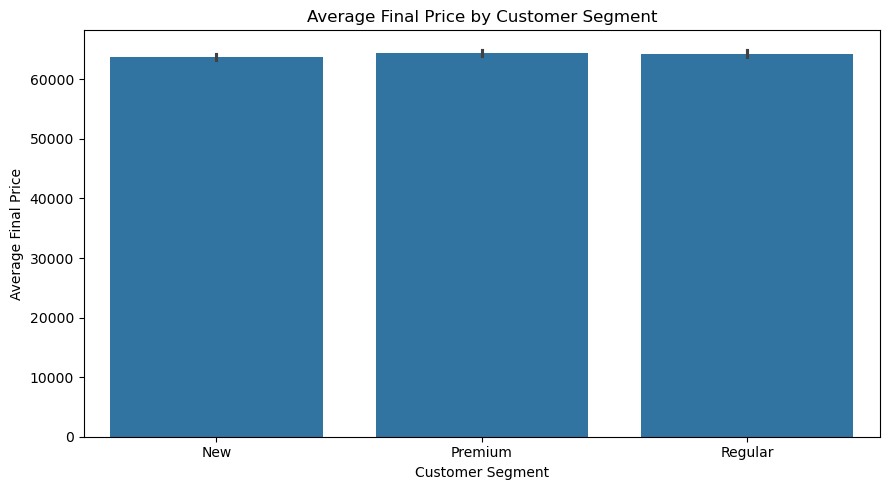

In [118]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_eda,
    x='customer_segment',
    y='final_price',
    errorbar=('ci', 95)
)

plt.title('Average Final Price by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Final Price')
plt.tight_layout()
plt.show()

### Customer Segment vs Final Price — Interpretation

The average final transaction price is highest for Premium customers
(₹64,430.45), followed by Regular customers (₹64,303.15) and New customers
(₹63,766.75).

Although Premium customers have the highest average transaction value, the
differences between the three segments are relatively small. The boxplot also
shows substantial overlap in the distributions, indicating that customer
segment does not strongly separate transaction values in this dataset.

The confidence-interval visualization confirms that the estimated group means
are precise, although statistical precision should not be confused with a
large practical difference between the groups.

## Product Category vs Return Rate

Return behavior is compared across product categories using return rate rather
than raw return counts. This provides a normalized comparison because the
categories contain slightly different numbers of transactions.

In [119]:
category_return_summary = (
    df_eda.groupby('product_category')
    .agg(
        total_transactions=('return_status', 'size'),
        returned_transactions=('return_status', lambda x: (x == 'Yes').sum())
    )
)

category_return_summary['return_rate'] = (
    category_return_summary['returned_transactions']
    / category_return_summary['total_transactions']
    * 100
)

category_return_summary = category_return_summary.sort_values(
    'return_rate',
    ascending=False
)

category_return_summary

,total_transactions,returned_transactions,return_rate
product_category,,,
Fashion,16613,2500,15.05
Home & Kitchen,16848,2508,14.89
Grocery,16592,2467,14.87
Health,16858,2500,14.83
Beauty,16513,2437,14.76
Electronics,16576,2399,14.47


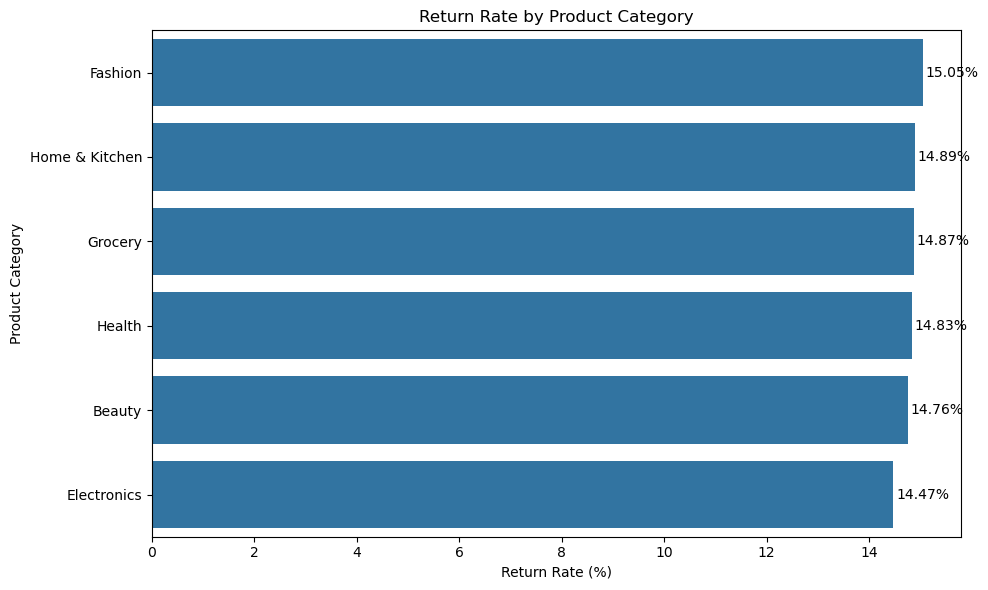

In [120]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_return_summary.reset_index(),
    x='return_rate',
    y='product_category'
)

for i, value in enumerate(category_return_summary['return_rate']):
    ax.text(
        value + 0.05,
        i,
        f'{value:.2f}%',
        va='center'
    )

plt.title('Return Rate by Product Category')
plt.xlabel('Return Rate (%)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### Product Category vs Return Rate — Observation

Return rates are relatively similar across all six product categories, ranging
from 14.47% for Electronics to 15.05% for Fashion.

Fashion has the highest return rate at 15.05%, followed by Home & Kitchen at
14.89%, Grocery at 14.87%, Health at 14.83% and Beauty at 14.76%.
Electronics has the lowest return rate at 14.47%.

### Interpretation

The relatively narrow range of return rates indicates that product category
does not create a large difference in overall return frequency within this
dataset.

Although Fashion has the highest observed return rate and Electronics the
lowest, the difference is only 0.58 percentage points. Therefore, category
alone does not appear to be a strong differentiating factor for return
behavior.

This differs from the Electronics-focused example in the project
specification, demonstrating the importance of interpreting the actual
dataset rather than assuming the example findings will necessarily occur.

## Shipping Type vs Delivery Days

Delivery performance is compared between Express and Standard shipping to
determine whether the shipping method is associated with differences in
delivery duration.

In [121]:
shipping_delivery_summary = (
    df_eda.groupby('shipping_type')['delivery_days']
    .agg(['mean', 'median', 'min', 'max'])
)

shipping_delivery_summary

,mean,median,min,max
shipping_type,,,,
Express,5.50,5.00,1,10
Standard,5.51,6.00,1,10


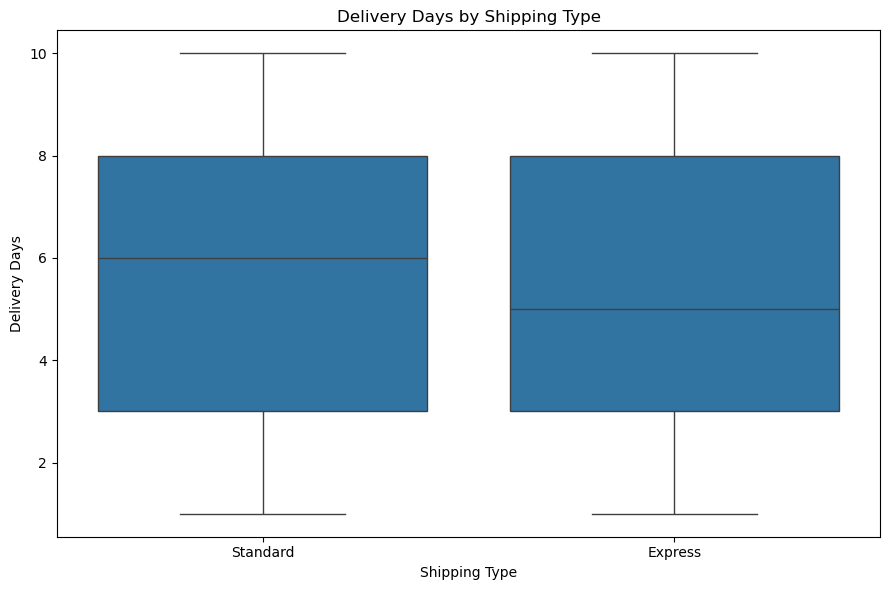

In [122]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_eda,
    x='shipping_type',
    y='delivery_days'
)

plt.title('Delivery Days by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.show()

### Shipping Type vs Delivery Days — Observation

Delivery durations range from 1 to 10 days for both Express and Standard
shipping.

The average delivery time is 5.50 days for Express shipping and 5.51 days
for Standard shipping, while the median delivery time is 5 days for Express
and 6 days for Standard shipping.

The boxplots show substantial overlap between the two distributions, with very
similar overall ranges and spreads.

### Interpretation

The dataset does not show a substantial difference in average delivery time
between Express and Standard shipping. Express shipping has a slightly lower
median delivery time, but the mean difference is only 0.01 days.

Therefore, shipping type alone does not appear to have a strong effect on
delivery duration in this dataset.

This differs from the example interpretation in the project specification,
which suggests that Express shipping significantly reduces delivery days.
The actual dataset does not provide evidence of such a large difference.

## Shipping Type vs Return Rate

Return behavior is compared between Express and Standard shipping using return
rate. This helps determine whether the shipping method is associated with
differences in the likelihood of a transaction being returned.

In [123]:
shipping_return_summary = (
    df_eda.groupby('shipping_type')
    .agg(
        total_transactions=('return_status', 'size'),
        returned_transactions=('return_status', lambda x: (x == 'Yes').sum())
    )
)

shipping_return_summary['return_rate'] = (
    shipping_return_summary['returned_transactions']
    / shipping_return_summary['total_transactions']
    * 100
)

shipping_return_summary

,total_transactions,returned_transactions,return_rate
shipping_type,,,
Express,50008,7457,14.91
Standard,49992,7354,14.71


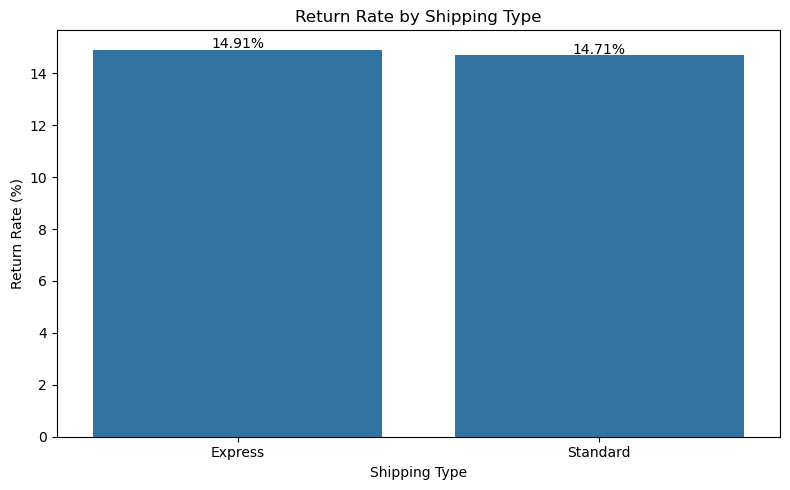

In [124]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=shipping_return_summary.reset_index(),
    x='shipping_type',
    y='return_rate'
)

for i, value in enumerate(shipping_return_summary['return_rate']):
    ax.text(
        i,
        value + 0.05,
        f'{value:.2f}%',
        ha='center'
    )

plt.title('Return Rate by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()

### Shipping Type vs Return Rate — Observation

The return rates for Express and Standard shipping are very similar. Express
shipping has a return rate of 14.91%, while Standard shipping has a return
rate of 14.71%.

The difference between the two shipping types is only 0.20 percentage points.

### Interpretation

Shipping type does not appear to create a substantial difference in return
rates within this dataset. Although Express shipping has a slightly higher
observed return rate, the difference is small.

Together with the earlier finding that Express and Standard shipping also have
nearly identical average delivery times, the results do not indicate a strong
relationship between shipping type and return behavior at the overall level.

## Delivery Days vs Return Rate

Return behavior is examined across different delivery durations to determine
whether longer delivery times are associated with changes in the proportion of
returned transactions.

In [125]:
delivery_return_summary = (
    df_eda.groupby('delivery_days')
    .agg(
        total_transactions=('return_status', 'size'),
        returned_transactions=('return_status', lambda x: (x == 'Yes').sum())
    )
)

delivery_return_summary['return_rate'] = (
    delivery_return_summary['returned_transactions']
    / delivery_return_summary['total_transactions']
    * 100
)

delivery_return_summary

,total_transactions,returned_transactions,return_rate
delivery_days,,,
1,9937,1488,14.97
2,9988,1467,14.69
3,9934,1466,14.76
4,10017,1476,14.73
5,10204,1476,14.46
6,10017,1467,14.65
7,9923,1526,15.38
8,9774,1468,15.02
9,10064,1506,14.96


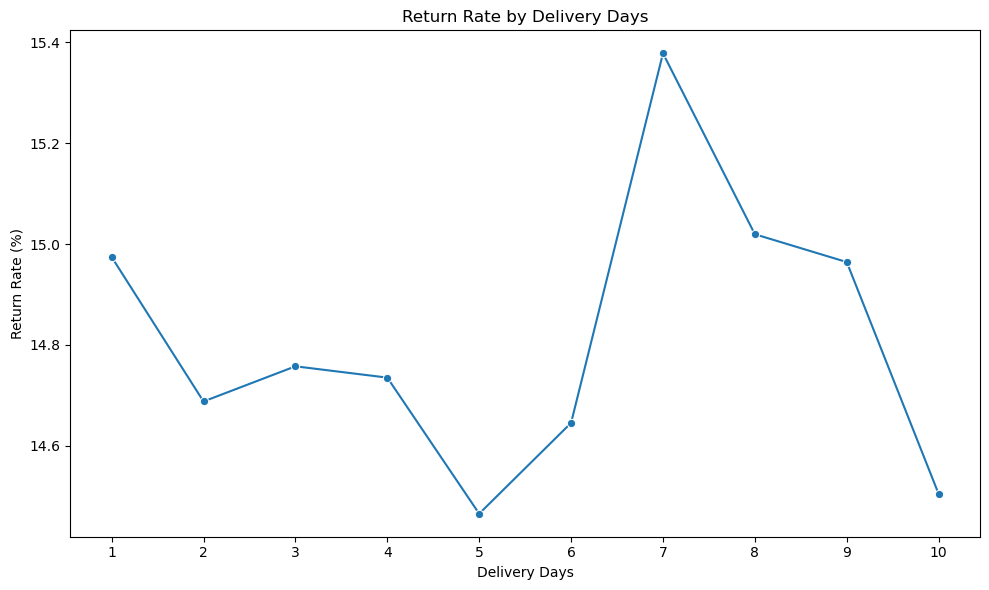

In [126]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=delivery_return_summary.reset_index(),
    x='delivery_days',
    y='return_rate',
    marker='o'
)

plt.title('Return Rate by Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Return Rate (%)')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

### Delivery Days vs Return Rate — Observation

Return rates fluctuate across delivery durations rather than increasing
consistently as delivery time increases. The return rate ranges from 14.46%
at 5 days to 15.38% at 7 days.

The highest return rate occurs at 7 delivery days, while the lowest occurs at
5 days. The return rate then decreases again at longer durations, reaching
14.50% at 10 days.


### Spearman correlation

In [127]:
delivery_return_spearman = (
    delivery_return_summary.reset_index()[['delivery_days', 'return_rate']]
    .corr(method='spearman')
    .loc['delivery_days', 'return_rate']
)

print(f"Spearman correlation: {delivery_return_spearman:.4f}")

Spearman correlation: -0.0061


### Delivery Days vs Return Rate — Final Interpretation

The Spearman correlation between delivery days and return rate is -0.0061,
which is effectively zero. This confirms that there is no meaningful monotonic
relationship between delivery duration and return rate in the dataset.

The line chart also shows that return rates fluctuate across delivery durations
without following a consistent upward or downward trend.

Therefore, delivery duration alone does not appear to be a strong indicator of
return behavior. Understanding returns may require considering multiple factors
simultaneously, which will be explored further in multivariate analysis.

## 5.3 Categorical × Categorical Analysis

### Customer Segment vs Product Category

The distribution of product categories is compared across customer segments to
determine whether New, Regular and Premium customers exhibit different product
preferences.

In [128]:
segment_category_pct = pd.crosstab(
    df_eda['customer_segment'],
    df_eda['product_category'],
    normalize='index'
) * 100

segment_category_pct.round(2)

product_category,Beauty,Electronics,Fashion,Grocery,Health,Home & Kitchen
customer_segment,,,,,,
New,16.28,16.51,16.73,17.06,16.67,16.74
Premium,16.83,16.42,16.38,16.56,16.85,16.96
Regular,16.43,16.79,16.73,16.16,17.05,16.85


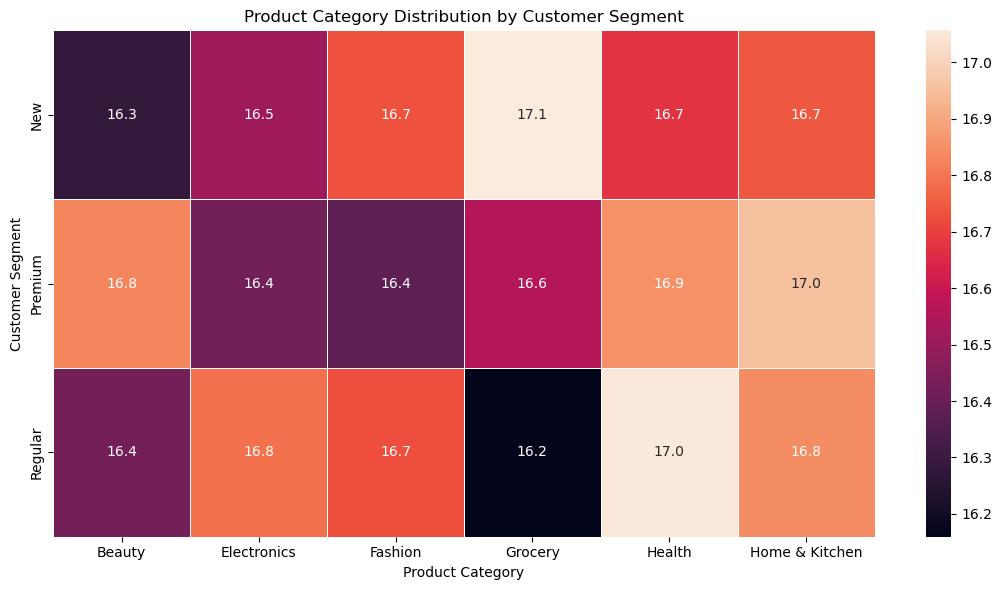

In [129]:
plt.figure(figsize=(11, 6))

sns.heatmap(
    segment_category_pct,
    annot=True,
    fmt='.1f',
    linewidths=0.5
)

plt.title('Product Category Distribution by Customer Segment')
plt.xlabel('Product Category')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

### Customer Segment vs Product Category — Observation

The normalized distribution of product categories is highly similar across
New, Premium and Regular customer segments. The category shares for all three
segments remain within a narrow range of approximately 16% to 17%.

For New customers, Grocery has the highest category share at 17.06%.
For Premium customers, Home & Kitchen has the highest share at 16.96%.
For Regular customers, Health has the highest share at 17.05%.

### Interpretation

The product-category mix does not differ substantially across customer
segments in this dataset. No customer segment shows a strong concentration in
a particular product category.

Therefore, customer segment and product category appear to have only a weak
association at the descriptive level. The balanced pattern suggests that the
three customer segments purchase across the product categories in broadly
similar proportions.

### Payment Method vs Return Rate

Return behavior is compared across payment methods using return rate. This
provides a normalized comparison of the likelihood of a transaction being
returned for each payment method.

In [130]:
payment_return_summary = (
    df_eda.groupby('payment_method')
    .agg(
        total_transactions=('return_status', 'size'),
        returned_transactions=('return_status', lambda x: (x == 'Yes').sum())
    )
)

payment_return_summary['return_rate'] = (
    payment_return_summary['returned_transactions']
    / payment_return_summary['total_transactions']
    * 100
)

payment_return_summary = payment_return_summary.sort_values(
    'return_rate',
    ascending=False
)

payment_return_summary

,total_transactions,returned_transactions,return_rate
payment_method,,,
UPI,25139,3771,15.00
Cash on Delivery,24994,3728,14.92
Debit Card,24560,3609,14.69
Credit Card,25307,3703,14.63


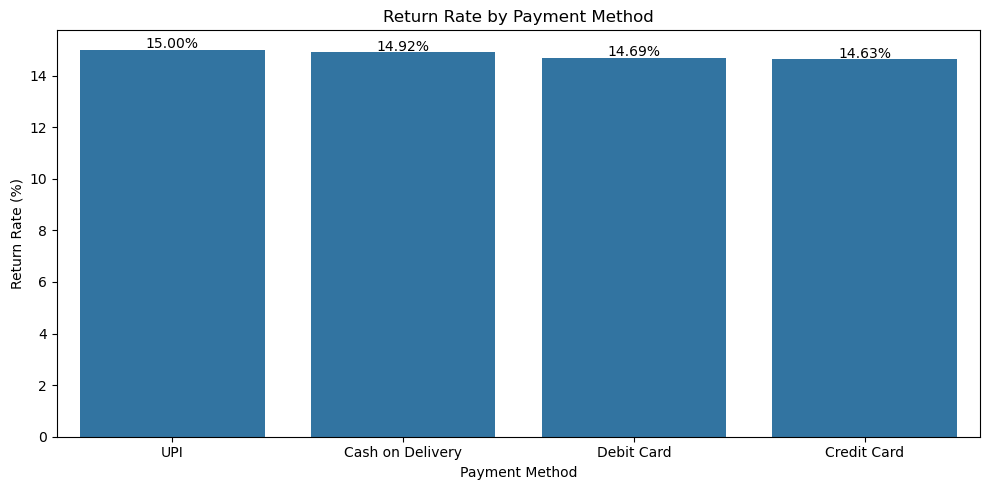

In [131]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=payment_return_summary.reset_index(),
    x='payment_method',
    y='return_rate'
)

for i, value in enumerate(payment_return_summary['return_rate']):
    ax.text(
        i,
        value + 0.05,
        f'{value:.2f}%',
        ha='center'
    )

plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()

### Payment Method vs Return Rate — Observation

Return rates are relatively similar across all four payment methods. UPI has
the highest return rate at 15.00%, followed by Cash on Delivery at 14.92%,
Debit Card at 14.69% and Credit Card at 14.63%.

The difference between the highest and lowest return rates is only 0.37
percentage points.

### Interpretation

The small variation in return rates suggests that payment method does not
create a substantial difference in return behavior within this dataset.

Although UPI has the highest observed return rate and Credit Card the lowest,
the overall return rates remain very close. Therefore, payment method alone
does not appear to be a strong differentiating factor for returns.

## 5.4 Bivariate Analysis — Key Findings

The bivariate analysis examined numerical-to-numerical,
numerical-to-categorical and categorical relationships.

Key findings include:

- `product_price` and `final_price` show a strong positive linear association.
- `quantity` is associated with substantially higher final transaction values.
- `age` and `delivery_days` show essentially no linear relationship with
  `final_price`.
- Customer segments have broadly similar final-price distributions.
- Product-category return rates are relatively close, with Fashion highest
  and Electronics lowest.
- Express and Standard shipping show almost identical delivery-time
  distributions and return rates.
- Return rates also vary only slightly across payment methods.
- Delivery-day return rates fluctuate without a consistent increasing or
  decreasing pattern, supported by a Spearman correlation of -0.0061.

These findings indicate that individual variables often provide limited
explanation on their own, motivating further multivariate analysis of combined
factors.

# 6. Multivariate Analysis

Multivariate analysis examines the interaction of three or more variables
simultaneously. It helps identify patterns that may not be visible when
variables are examined individually or in pairs.

The multivariate analysis in this project focuses on the relationships
specified in the project requirements while adapting them to the variables
available in the actual retail transaction dataset.

## 6.1 Product Category × Discount Percentage × Final Price

The interaction between product category, discount percentage and final
transaction price is analyzed to understand whether final transaction values
vary across discount levels and whether these patterns differ between product
categories.

Instead of plotting individual transactions, average final price is calculated
for each product-category and discount-level combination. This aggregation
reduces visual clutter while preserving the underlying relationship.

In [142]:
category_discount_price = (
    df_eda
    .groupby(['product_category', 'discount_percentage'])['final_price']
    .mean()
    .unstack()
)

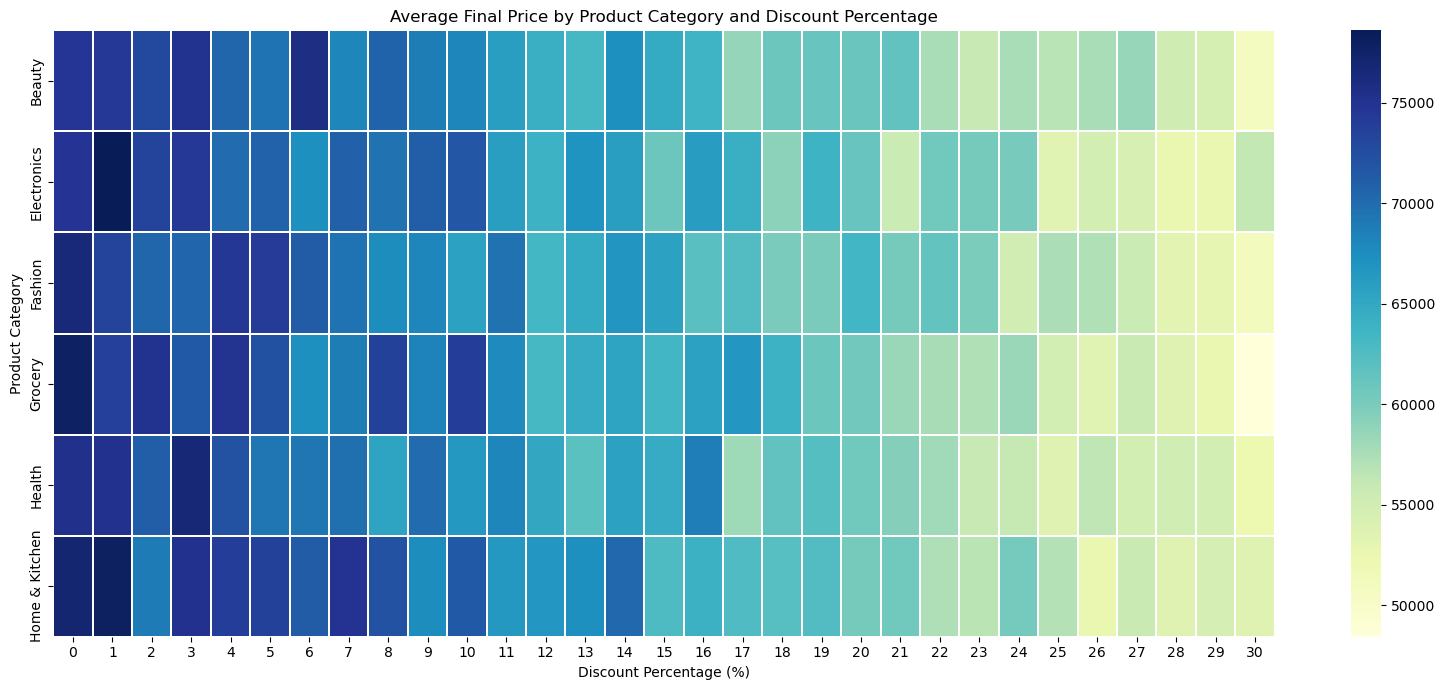

In [139]:
plt.figure(figsize=(16, 7))

sns.heatmap(
    category_discount_price,
    cmap='YlGnBu',
    linewidths=0.3
)

plt.title(
    'Average Final Price by Product Category and Discount Percentage'
)
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [143]:
discount_price_summary = (
    df_eda
    .groupby('discount_percentage')['final_price']
    .agg(['mean', 'median'])
)

discount_price_summary.loc[[0, 5, 10, 15, 20, 25, 30]].round(2)


,mean,median
discount_percentage,,
0,76029.98,58028.50
5,71634.63,55009.27
10,69584.76,53305.65
15,63741.75,48558.80
20,61200.51,47363.60
25,55532.02,41803.50
30,52051.12,39533.90


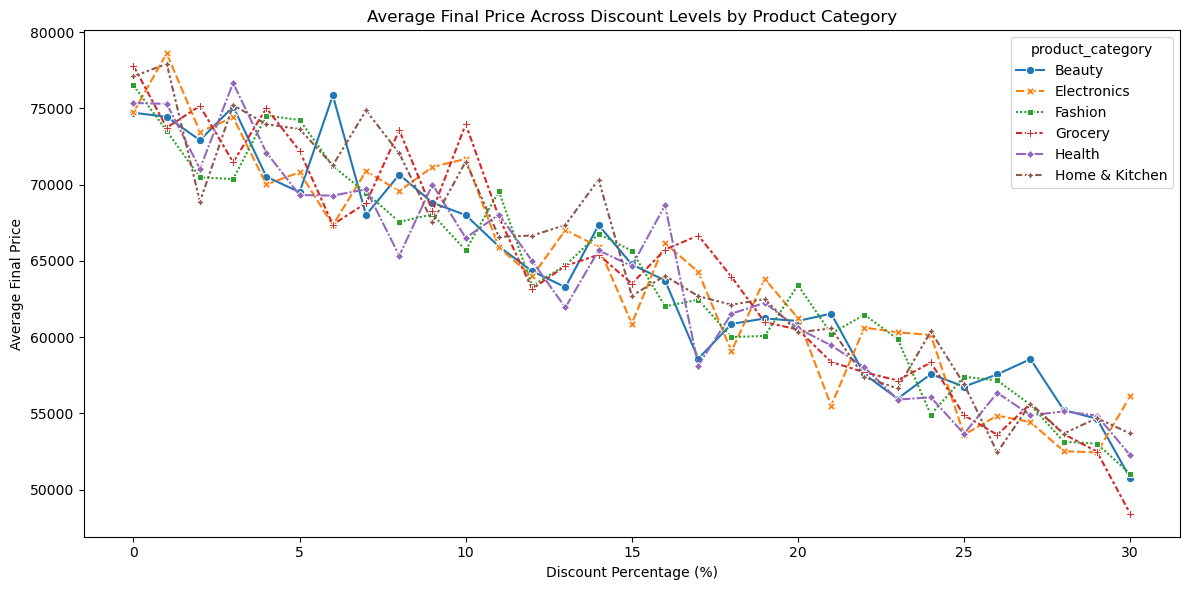

In [144]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=category_discount_price.T,
    markers=True
)

plt.title(
    'Average Final Price Across Discount Levels by Product Category'
)
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Average Final Price')

plt.tight_layout()
plt.show()

### Product Category × Discount Percentage × Final Price — Observation

The multivariate analysis shows a general decline in average final transaction
price as discount percentage increases. Across the dataset, the average final
price decreases from ₹76,029.98 at 0% discount to ₹52,051.12 at 30% discount.

The heatmap and category-specific trend lines show that this downward pattern
is broadly consistent across all six product categories, although individual
discount levels contain some fluctuations.

No product category demonstrates a fundamentally different overall discount–
price pattern.

### Interpretation

Higher discount percentages are associated with lower average final
transaction prices across the product categories. The similar patterns across
categories suggest that the effect observed at the aggregate level is not
restricted to a single product category.

However, final price is also determined by product price and quantity in this
dataset. Therefore, the observed decline should be interpreted as an
association within the transaction data rather than as evidence that discount
percentage alone causes the change in final transaction price.

The example in the project specification suggests that moderate discounts
may generate the highest revenue for Electronics, but this specific pattern is
not observed in the present dataset.

## 6.2 Customer Segment × Age × Final Price

The interaction between customer segment, age and final transaction price is
examined to determine whether transaction-value patterns across age groups
differ between New, Regular and Premium customers.

Since the dataset does not contain a separate spending variable, `final_price`
is used as the available transaction-value measure.

A faceted visualization is used to separate customer segments while preserving
the age-to-price relationship within each group.

In [145]:
segment_age_sample = df_eda.sample(
    9000,
    random_state=42
)

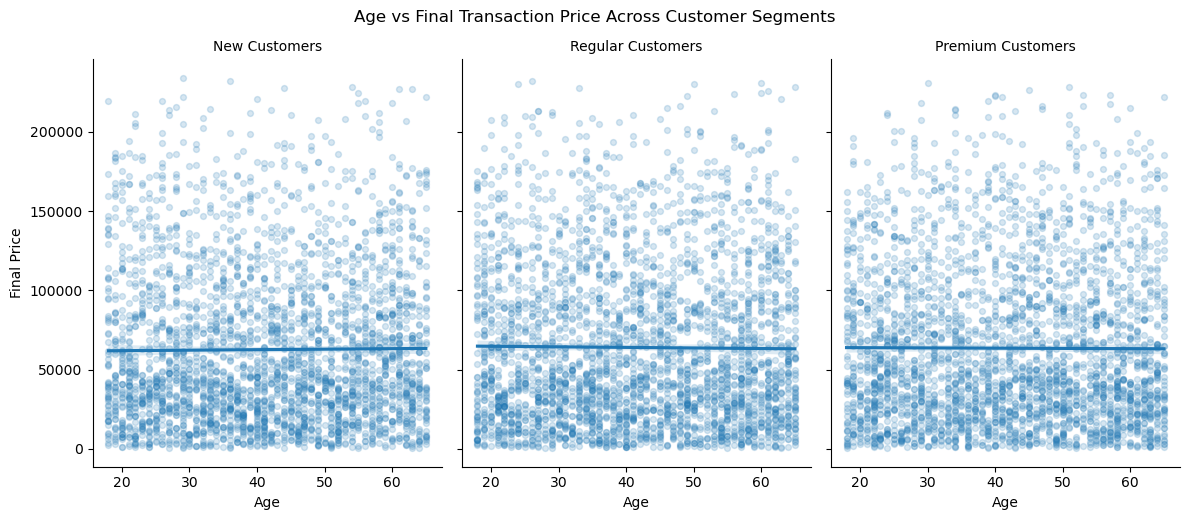

In [146]:
g = sns.lmplot(
    data=segment_age_sample,
    x='age',
    y='final_price',
    col='customer_segment',
    col_order=['New', 'Regular', 'Premium'],
    height=5,
    aspect=0.8,
    scatter_kws={'alpha': 0.18, 's': 18},
    line_kws={}
)

g.set_axis_labels('Age', 'Final Price')
g.set_titles('{col_name} Customers')
g.fig.suptitle(
    'Age vs Final Transaction Price Across Customer Segments',
    y=1.03
)

plt.show()

In [152]:
segment_age_corr = pd.DataFrame({
    'Pearson Correlation': [
        df_eda.loc[
            df_eda['customer_segment'] == segment,
            'age'
        ].corr(
            df_eda.loc[
                df_eda['customer_segment'] == segment,
                'final_price'
            ]
        )
        for segment in ['New', 'Regular', 'Premium']
    ]
}, index=['New', 'Regular', 'Premium'])

segment_age_corr

,Pearson Correlation
New,-0.00
Regular,0.00
Premium,-0.00


In [149]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = [
    '18–25',
    '26–35',
    '36–45',
    '46–55',
    '56–65'
]

df_eda['age_group'] = pd.cut(
    df_eda['age'],
    bins=age_bins,
    labels=age_labels
)

In [150]:
age_segment_summary = (
    df_eda
    .groupby(['customer_segment', 'age_group'], observed=False)['final_price']
    .mean()
    .unstack()
)

age_segment_summary.round(2)

age_group,18–25,26–35,36–45,46–55,56–65
customer_segment,,,,,
New,63588.34,64164.81,63878.65,63512.56,63659.29
Premium,64025.80,65281.87,64033.64,65432.07,63294.74
Regular,64097.15,64359.16,64103.87,64294.84,64616.06


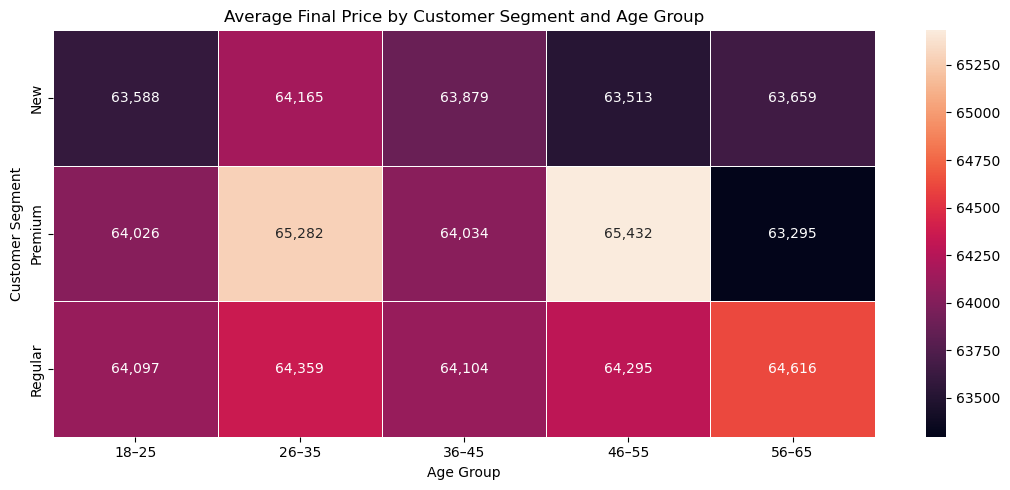

In [151]:
plt.figure(figsize=(11, 5))

sns.heatmap(
    age_segment_summary,
    annot=True,
    fmt=',.0f',
    linewidths=0.5
)

plt.title('Average Final Price by Customer Segment and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

### Customer Segment × Age × Final Price — Observation

The faceted scatter plots show substantial dispersion in final transaction
prices across all age levels and customer segments. The trend lines within
each segment remain approximately horizontal.

The segment-wise Pearson correlations between age and final transaction price
are all approximately zero, indicating no meaningful linear relationship within
any customer segment.

The age-group heatmap shows some variation in average final price across
segments and age groups, but the differences are relatively modest and do not
follow a consistent age-based pattern.

### Interpretation

Customer segment does not substantially change the relationship between age
and final transaction price. Age therefore does not appear to be a strong
linear indicator of transaction value even when customer segments are
considered separately.

Premium customers record their highest average final price in the 46–55 age
group (₹65,432.07), while the lowest occurs in the 56–65 group (₹63,294.74).
However, the variation is relatively small and does not establish a clear
age-driven pattern.

The example pattern described in the project specification for Premium
customers aged 30–45 is not observed in this dataset.

## 6.3 Delivery Days × Shipping Type × Return Status

The interaction between delivery duration, shipping type and return behavior is
examined to determine whether return rates vary across delivery durations
differently for Express and Standard shipping.

Return rate is used instead of raw return counts so that delivery durations can
be compared fairly.

In [157]:
# Calculating return rate for each delivery-day and shipping-type combination

delivery_shipping_return = (
    df_eda
    .groupby(['shipping_type', 'delivery_days'])
    .agg(
        total_transactions=('return_status', 'size'),
        returned_transactions=(
            'return_status',
            lambda x: (x == 'Yes').sum()
        )
    )
)

delivery_shipping_return['return_rate'] = (
    delivery_shipping_return['returned_transactions']
    / delivery_shipping_return['total_transactions']
    * 100
)

In [156]:
return_rate_heatmap = (
    delivery_shipping_return['return_rate']
    .unstack(level='shipping_type')
)

return_rate_heatmap.round(2)

shipping_type,Express,Standard
delivery_days,,
1,14.74,15.21
2,14.57,14.80
3,15.21,14.30
4,14.58,14.89
5,15.09,13.83
6,14.37,14.92
7,16.21,14.53
8,14.76,15.28
9,14.76,15.17


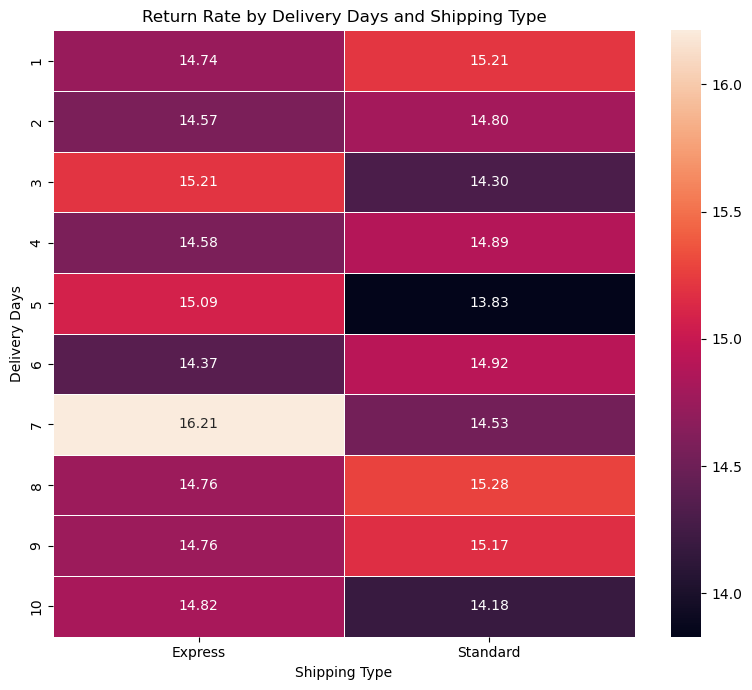

In [158]:
plt.figure(figsize=(8, 7))

sns.heatmap(
    return_rate_heatmap,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Return Rate by Delivery Days and Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')

plt.tight_layout()
plt.show()

### Delivery Days × Shipping Type × Return Status — Observation

Return rates vary across delivery durations within both Express and Standard
shipping, but no consistent increasing or decreasing pattern is observed.

For Express shipping, the highest return rate occurs at 7 delivery days
(16.21%), while the rates at 8–10 days return to approximately 14.8%.

For Standard shipping, the return rate ranges from 13.83% at 5 days to 15.28%
at 8 days, followed by a decline to 14.18% at 10 days.

### Interpretation

The interaction between delivery duration and shipping type does not reveal a
clear systematic relationship with return behavior. Although certain
combinations show higher or lower return rates, these differences do not
follow a consistent trend as delivery time increases.

Therefore, longer delivery duration cannot be considered a reliable standalone
indicator of returns in this dataset, even when shipping type is taken into
account.

This differs from the example pattern described in the project specification,
which suggests higher return probability for longer delivery times under
Standard shipping. The present dataset does not show that consistent pattern.

# 7. Correlation Analysis

## 7.1 Pearson Correlation Analysis

Pearson correlation is used to measure the strength and direction of linear
relationships among the numerical variables.

Correlation coefficients range from -1 to +1:

- Values close to +1 indicate a strong positive linear relationship.
- Values close to -1 indicate a strong negative linear relationship.
- Values close to 0 indicate little or no linear relationship.

Identifier and categorical variables are excluded because Pearson correlation
is intended here for the numerical analytical variables.

In [159]:
correlation_matrix = df_eda[numerical_columns].corr(method='pearson')

correlation_matrix.round(2)

,age,product_price,quantity,discount_percentage,final_price,delivery_days
age,1.00,-0.00,-0.00,-0.00,-0.00,-0.00
product_price,-0.00,1.00,0.00,-0.00,0.73,0.00
quantity,-0.00,0.00,1.00,-0.00,0.58,0.00
discount_percentage,-0.00,-0.00,-0.00,1.00,-0.14,-0.00
final_price,-0.00,0.73,0.58,-0.14,1.00,0.00
delivery_days,-0.00,0.00,0.00,-0.00,0.00,1.00


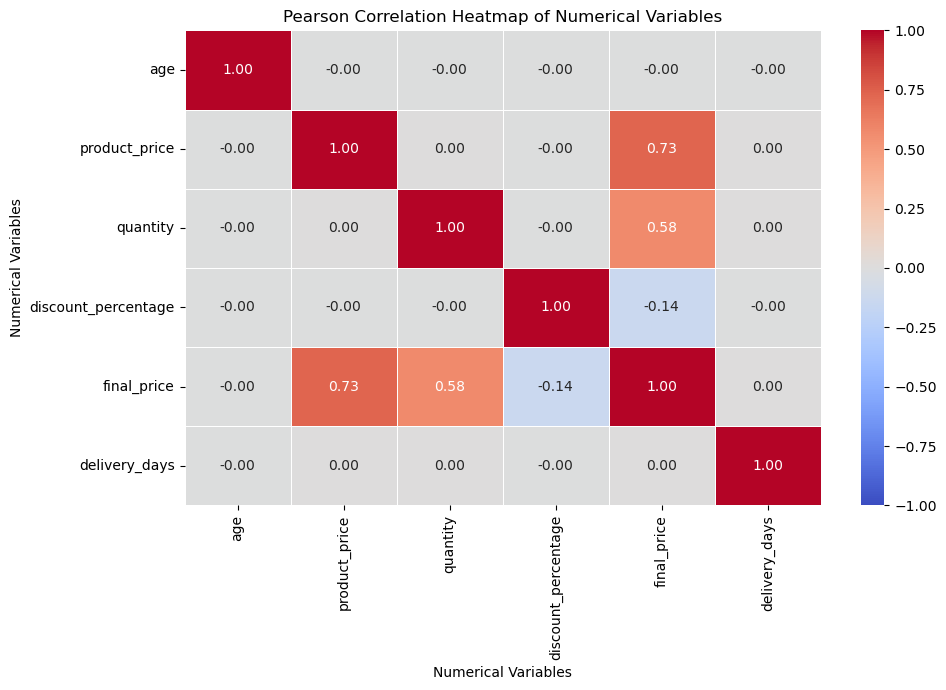

In [160]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
    cmap='coolwarm'
)

plt.title('Pearson Correlation Heatmap of Numerical Variables')
plt.xlabel('Numerical Variables')
plt.ylabel('Numerical Variables')

plt.tight_layout()
plt.show()

In [164]:
# Extracting unique correlation pairs

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    'Variable 1',
    'Variable 2',
    'Correlation'
]

correlation_pairs['Absolute Correlation'] = (
    correlation_pairs['Correlation'].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    'Absolute Correlation',
    ascending=False
)

meaningful_correlations = correlation_pairs[
    correlation_pairs['Absolute Correlation'] >= 0.10
].round(4)

meaningful_correlations

,Variable 1,Variable 2,Correlation,Absolute Correlation
7,product_price,final_price,0.73,0.73
10,quantity,final_price,0.58,0.58
12,discount_percentage,final_price,-0.14,0.14


In [162]:
strongest_positive = correlation_pairs.loc[
    correlation_pairs['Correlation'].idxmax()
]

strongest_negative = correlation_pairs.loc[
    correlation_pairs['Correlation'].idxmin()
]

print("Strongest positive relationship:")
print(strongest_positive)

print("\nStrongest negative relationship:")
print(strongest_negative)

Strongest positive relationship:
Variable 1              product_price
Variable 2                final_price
Correlation                      0.73
Absolute Correlation             0.73
Name: 7, dtype: object

Strongest negative relationship:
Variable 1              discount_percentage
Variable 2                      final_price
Correlation                           -0.14
Absolute Correlation                   0.14
Name: 12, dtype: object


### Correlation Analysis — Observation

The Pearson correlation matrix shows that `product_price` has the strongest
positive linear relationship with `final_price`, with a correlation of 0.73.
`quantity` also shows a moderate-to-strong positive relationship with
`final_price`, with a correlation of 0.58.

`discount_percentage` has a weak negative correlation with `final_price`
(-0.14), consistent with the earlier observation that higher discounts are
generally associated with lower average final transaction prices.

The remaining numerical variable pairs have correlations approximately equal
to zero, indicating little or no meaningful linear association.

### Interpretation

The correlation structure indicates that final transaction value is most
closely associated with direct pricing factors, particularly product price and
order quantity. Discount percentage has a comparatively weak negative linear
association, while customer age and delivery duration show virtually no linear
relationship with final price.

The strong correlations involving `final_price` are also consistent with the
pricing formula validated earlier, in which product price, quantity and
discount percentage are components of the final transaction value.

Correlation measures linear association and should not by itself be
interpreted as evidence of causation.